## 1. 分析目標

- 專案目標：探討跨星級飯店的評論分類模型,能否從評論內容預測飯店星級
- 訓練/測試資料：以 5 星、4 星、3 星、2 星飯店的 TripAdvisor 評論 (7:3 切分)
    - 四家飯店分別為各星級中評論數最多的一家

- 重點：
    - 模型能否從評論內容 (`content`) 正確分類出飯店星級 (`hotel_class`)
    - 不同星級飯店在評論內容與用字風格上的差異
    - 分析分類準確度與表現落差背後的原因

In [181]:
import re
from pprint import pprint

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import jieba
from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict, KFold
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    RocCurveDisplay
)
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import LabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm

設定中文字體

In [182]:
# 設定圖的中文字體 (Windows 使用 Microsoft JhengHei)
# 也可參考：https://pyecontech.com/2020/03/27/python_matplotlib_chinese/
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] #使圖中中文能正常顯示
plt.rcParams['axes.unicode_minus'] = False #使負號能夠顯示

## 2. 文字前處理
本次分析使用四個星級飯店的 TripAdvisor 評論資料(`5star.xlsx`、`4star.xlsx`、`3star.xlsx`、`2star.xlsx`)。
- 資料內容：各星級代表的飯店中評論數最多的那一家
- 原始欄位：reviewer, location, contributions, user_helpful_votes, date_posted, rating, title, content, stay_date, trip_type
- 本次分析主要使用 `content` 欄位作為輸入文字、`hotel_class` 作為分類標籤

先讀取資料並做基本前處理。

In [183]:
# 讀取四個星級的飯店評論 (Excel 檔請先 pip install openpyxl)
df5 = pd.read_excel("raw_data2/5star.xlsx")
df4 = pd.read_excel("raw_data2/4star.xlsx")
df3 = pd.read_excel("raw_data2/3star.xlsx")
df2 = pd.read_excel("raw_data2/2star.xlsx")

# 加上 hotel_class 標記當作分類 label
df5["hotel_class"] = "5star"
df4["hotel_class"] = "4star"
df3["hotel_class"] = "3star"
df2["hotel_class"] = "2star"

# 四家全部合併 (對應原範本的 dcard)
dcard = pd.concat([df5, df4, df3, df2], ignore_index=True)

# 原範本 artUrl 是文章連結,這邊用 index 補上唯一 ID
dcard["artUrl"] = "review_" + dcard.index.astype(str)

dcard.head(3)

,reviewer,location,contributions,user_helpful_votes,date_posted,rating,title,content,stay_date,trip_type,hotel_class,artUrl
0,JennyYu 已於 2024年11月 發表一則評論,月 發表一則評論\n台灣台北,225.0,6.0,2024年11月,5,✨【愛上高雄漢來飯店的原因】✨,✨【愛上高雄漢來飯店的原因】✨\n這次帶著喜歡庫洛米的Yoyo，入住高雄漢來飯店的三麗鷗主題...,NaN,NaN,5star,review_0
1,ANDYCKH 已於 2024年8月 發表一則評論,月 發表一則評論\n香港,91.0,1.0,2024年8月,5,超可愛Kuromi主題房,"復活節假期帶老婆到高雄看5月天演唱會, 住了3晚漢來大飯店, 原因100%是因為有Kurom...",NaN,NaN,5star,review_1
2,IG denden.travel 已於 2023年12月 發表一則評論,月 發表一則評論\n台灣台北,2465.0,27.0,2023年12月,5,大概是全世界最用心的三麗鷗主題房,大概是全世界最用心的三麗鷗主題房～\n大家好，我是膚淺喜歡被讚美的丹丹，這篇要介紹的是高雄漢...,NaN,NaN,5star,review_2


In [184]:
# 看看有幾則評論
print(f"number of reviews: {dcard.shape[0]}")
print(f"date range: {(dcard['date_posted'].min(), dcard['date_posted'].max())}")
print(f"hotel_class distribution:\n{dcard['hotel_class'].value_counts()}")

number of reviews: 4938
date range: ('2005年11月', '2025年3月')
hotel_class distribution:
hotel_class
4star    2492
3star    1474
5star     497
2star     475
Name: count, dtype: int64


+ 2.1 斷句
+ 2.2 斷詞（刪掉次數太少的、標點符號、停用字）

### 2.1 清理

利用問號、句號或驚嘆號等符號斷句，或是如果出現中文或是英文的省略號，像是`...`也會斷句，最後設定會去除結尾的空白符號。

In [185]:
# 過濾 nan 的資料
dcard = dcard.dropna(subset=['content'])
dcard = dcard.dropna(subset=['hotel_class'])

# 移除網址格式
dcard["content"] = dcard["content"].astype(str).apply(
    lambda x: re.sub("(http|https)://\\S+", "", x)
)

# 只留下中文字
dcard["content"] = dcard["content"].apply(
    lambda x: re.sub("[^\u4e00-\u9fa5]+", "", x)
)

# 清完可能會有空字串
dcard = dcard[dcard["content"].str.len() > 0].reset_index(drop=True)
dcard.head()

,reviewer,location,contributions,user_helpful_votes,date_posted,rating,title,content,stay_date,trip_type,hotel_class,artUrl
0,JennyYu 已於 2024年11月 發表一則評論,月 發表一則評論\n台灣台北,225.0,6.0,2024年11月,5,✨【愛上高雄漢來飯店的原因】✨,愛上高雄漢來飯店的原因這次帶著喜歡庫洛米的入住高雄漢來飯店的三麗鷗主題房我們選擇的是美樂蒂和...,NaN,NaN,5star,review_0
1,ANDYCKH 已於 2024年8月 發表一則評論,月 發表一則評論\n香港,91.0,1.0,2024年8月,5,超可愛Kuromi主題房,復活節假期帶老婆到高雄看月天演唱會住了晚漢來大飯店原因是因為有主題房老婆是超級酒店離地鐵站並...,NaN,NaN,5star,review_1
2,IG denden.travel 已於 2023年12月 發表一則評論,月 發表一則評論\n台灣台北,2465.0,27.0,2023年12月,5,大概是全世界最用心的三麗鷗主題房,大概是全世界最用心的三麗鷗主題房大家好我是膚淺喜歡被讚美的丹丹這篇要介紹的是高雄漢來大飯店三...,NaN,NaN,5star,review_2
3,fang2002 已於 2023年5月 發表一則評論,月 發表一則評論\n台灣台北,35.0,12.0,2023年5月,4,10多年來慢慢老舊了,若活動範圍在南高雄算是可以選擇的酒店之一離捷運遠需利用計程車過去每年農曆春節常常會住這邊一晚...,NaN,NaN,5star,review_3
4,Wanderer09762283228 已於 2023年4月 發表一則評論,月 發表一則評論,1.0,NaN,2023年4月,4,單獨旅行分享心得,我覺得大廳環境不錯但走進去沒人理我好幾分鐘不知道哪裡入住最後是我自己問才知道是找有點久湯裡面...,NaN,NaN,5star,review_4


本次分析只使用評論內文 `content` 作為文字分析對象,不使用 `title`。

In [186]:
# 只留下會用到的欄位
dcard = dcard[["content", "artUrl", "hotel_class", "date_posted"]]
dcard.head()

,content,artUrl,hotel_class,date_posted
0,愛上高雄漢來飯店的原因這次帶著喜歡庫洛米的入住高雄漢來飯店的三麗鷗主題房我們選擇的是美樂蒂和...,review_0,5star,2024年11月
1,復活節假期帶老婆到高雄看月天演唱會住了晚漢來大飯店原因是因為有主題房老婆是超級酒店離地鐵站並...,review_1,5star,2024年8月
2,大概是全世界最用心的三麗鷗主題房大家好我是膚淺喜歡被讚美的丹丹這篇要介紹的是高雄漢來大飯店三...,review_2,5star,2023年12月
3,若活動範圍在南高雄算是可以選擇的酒店之一離捷運遠需利用計程車過去每年農曆春節常常會住這邊一晚...,review_3,5star,2023年5月
4,我覺得大廳環境不錯但走進去沒人理我好幾分鐘不知道哪裡入住最後是我自己問才知道是找有點久湯裡面...,review_4,5star,2023年4月


In [187]:
# 看看有幾篇文章
print(f"total docs: {dcard.shape[0]}")


total docs: 4936


### 2.2 斷詞

In [188]:
# 設定繁體中文詞庫
jieba.set_dictionary("./dict/dict.txt")

# 新增stopwords
# jieba.analyse.set_stop_words('./dict/stopwords.txt') #jieba.analyse.extract_tags才會作用
with open("./dict/stopwords.txt", encoding="utf-8") as f:
    stopWords = [line.strip() for line in f.readlines()]

In [189]:
# 設定斷詞 function
def getToken(row):
    seg_list = jieba.cut(row, cut_all=False)
    seg_list = [
        w for w in seg_list if w not in stopWords and len(w) > 1
    ]  # 篩選掉停用字與字元數大於1的詞彙
    return seg_list

In [190]:
dcard["words"] = dcard["content"].apply(getToken).map(" ".join)
dcard.head()

Building prefix dict from c:\Users\User\SMA_G2_PRJ1\dict\dict.txt ...
2026-04-24 11:08:22,788 : DEBUG : Building prefix dict from c:\Users\User\SMA_G2_PRJ1\dict\dict.txt ...
Loading model from cache C:\Users\User\AppData\Local\Temp\jieba.u39b885617fea8e30e122529cfb9d1eb6.cache
2026-04-24 11:08:22,792 : DEBUG : Loading model from cache C:\Users\User\AppData\Local\Temp\jieba.u39b885617fea8e30e122529cfb9d1eb6.cache
Loading model cost 0.347 seconds.
2026-04-24 11:08:23,139 : DEBUG : Loading model cost 0.347 seconds.
Prefix dict has been built successfully.
2026-04-24 11:08:23,139 : DEBUG : Prefix dict has been built successfully.


,content,artUrl,hotel_class,date_posted,words
0,愛上高雄漢來飯店的原因這次帶著喜歡庫洛米的入住高雄漢來飯店的三麗鷗主題房我們選擇的是美樂蒂和...,review_0,5star,2024年11月,愛上 高雄 漢來 飯店 原因 喜歡 庫洛米 入住 高雄 漢來 飯店 三麗鷗 主題房 選擇 美...
1,復活節假期帶老婆到高雄看月天演唱會住了晚漢來大飯店原因是因為有主題房老婆是超級酒店離地鐵站並...,review_1,5star,2024年8月,復活節 假期 老婆 高雄 看月天 演唱會 晚漢來 飯店 原因 主題房 老婆 酒店 地鐵站 並...
2,大概是全世界最用心的三麗鷗主題房大家好我是膚淺喜歡被讚美的丹丹這篇要介紹的是高雄漢來大飯店三...,review_2,5star,2023年12月,全世界 用心 三麗鷗 主題房 膚淺 喜歡 讚美 丹丹 這篇要 介紹 高雄 漢來 飯店 三麗鷗...
3,若活動範圍在南高雄算是可以選擇的酒店之一離捷運遠需利用計程車過去每年農曆春節常常會住這邊一晚...,review_3,5star,2023年5月,活動 範圍 高雄 算是 選擇 酒店 之一離 捷運 遠需 利用 計程車 過去 每年 農曆 春節...
4,我覺得大廳環境不錯但走進去沒人理我好幾分鐘不知道哪裡入住最後是我自己問才知道是找有點久湯裡面...,review_4,5star,2023年4月,大廳 環境 不錯 走進去 沒人理 幾分鐘 知道 入住 最後 問才 知道 久湯 裡面 料理 中...


### 2.3 資料集基本檢視

檢視資料內容

In [191]:
print(f"total reviews: {len(dcard['artUrl'].unique())}")
print(f"hotel_class distribution:\n{dcard['hotel_class'].value_counts()}")

total reviews: 4936
hotel_class distribution:
hotel_class
4star    2491
3star    1473
5star     497
2star     475
Name: count, dtype: int64


## 3. 分類模型的訓練流程
### 3.1 根據7:3的比例切分資料集
利用 sklearn 中的 train_test_split 函數將 `raw_data` 隨機切成 7:3，設置 random_state 讓每次切分的結果一致。`y_train`和`y_test`分別為訓練資料和測試資料的預測目標。

In [192]:
data = dcard
X = data["words"]
y = data["hotel_class"]

# 把整個資料集七三切
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=777, stratify=y
)

print(X_train.head())
print(y_train.head())

271     臺灣 酒店 安靜 房間 很棒 自助 早餐 晚餐 餐廳 第樓 中國 食物 優質 服務 推薦 地...
3735    入住 六人 房下 高雄 車站 三步 飯店 交通 方便 櫃檯 人員 服務 親切 詳細 解說 飯...
3244    入住 房間 清潔 乾淨 設備 方面 一再 改進 餐點 部分 越來越 入住 第二天 早上 餐廳...
1417    高興 來到 翰品 特殊 設置 貼心 感覺 房間 整潔 服務 到位 櫃檯 全方位 服務 窩心 ...
1706    停好 服務員 過來 協助 幫忙 指引 停車 方式 櫃台 服務 人員 耐心 幫忙 晚上 啤酒 ...
Name: words, dtype: object
271     5star
3735    3star
3244    3star
1417    4star
1706    4star
Name: hotel_class, dtype: object


In [193]:
# 看一下各個資料集切分的比例,應該要一致
print(
    f"raw data percentage :\n{data['hotel_class'].value_counts(normalize=True) * 100}"
)
print(f"\ntrain percentage :\n{y_train.value_counts(normalize=True) * 100}")
print(f"\ntest percentage :\n{y_test.value_counts(normalize=True) * 100}")

raw data percentage :
hotel_class
4star    50.465964
3star    29.841977
5star    10.068882
2star     9.623177
Name: proportion, dtype: float64

train percentage :
hotel_class
4star    50.477569
3star    29.840810
5star    10.072359
2star     9.609262
Name: proportion, dtype: float64

test percentage :
hotel_class
4star    50.438893
3star    29.844700
5star    10.060770
2star     9.655638
Name: proportion, dtype: float64


### 3.2 將文章轉為 DTM

DTM(document term matrix) :
+ 將不同的文章 (document) 以文章中出現過的字詞(term)表示
    + row 是document (文件)
    + column 是字詞 (term)
    + row 內的數字是出現的字數

DTM裡面的值可以有不同的表示方法
+ (1) 依據詞頻 (classic BoW)
    + 用 `CountVectorizer()`
    + unigrams and bigrams
    + [sklearn.feature_extraction.text.CountVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html)
+ (2) 依據tfidf (advanced variant of BoW)
    + 篩選出現次數大於10的字
    + 用 `TfidfVectorizer()`
    + [sklearn.feature_extraction.text.TfidfVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html)
+ 常用參數介紹
    + max_features: 取 詞頻 / tfidf 前多少的字

### 3.3 套入正式的資料集

模型訓練範例: logistic regression + cv tokenizer

In [194]:
vectorizer = CountVectorizer(max_features=1000)
print(vectorizer)

CountVectorizer(max_features=1000)


In [195]:
X_train.head()

271     臺灣 酒店 安靜 房間 很棒 自助 早餐 晚餐 餐廳 第樓 中國 食物 優質 服務 推薦 地...
3735    入住 六人 房下 高雄 車站 三步 飯店 交通 方便 櫃檯 人員 服務 親切 詳細 解說 飯...
3244    入住 房間 清潔 乾淨 設備 方面 一再 改進 餐點 部分 越來越 入住 第二天 早上 餐廳...
1417    高興 來到 翰品 特殊 設置 貼心 感覺 房間 整潔 服務 到位 櫃檯 全方位 服務 窩心 ...
1706    停好 服務員 過來 協助 幫忙 指引 停車 方式 櫃台 服務 人員 耐心 幫忙 晚上 啤酒 ...
Name: words, dtype: object

In [196]:
vec_train = vectorizer.fit_transform(X_train)
vocabulary = vectorizer.get_feature_names_out()

Count_df = pd.DataFrame(columns = vocabulary, data = vec_train.toarray())
Count_df

,一下,一位,一到,一夜,一大,一天,一家人,一張,一應俱全,一提,...,高雄,高雄市,鹽埕,鹽埕區,麥當勞,麵包,麻煩,點心,齊全,龍蝦
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3450,0,0,0,0,0,0,0,0,0,0,...,2,0,0,0,0,0,0,0,0,0
3451,0,0,0,0,0,0,0,0,0,0,...,2,0,0,0,0,0,0,0,0,0
3452,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
3453,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [197]:
# 不需重新 `fit()` data，因前面已經 `fit()` 過了
# 只需將測試數據使用之前訓練好的 vectorizer 轉換為相同的特徵表示形式，而不需要重新fit。
# 如果對測試數據再次 fit vectorizer，可能會導致使用了測試數據的信息，進而導致模型的不穩定性和過度擬合的問題。
vec_test = vectorizer.transform(X_test)
print(vec_train.shape)
print(vec_test.shape)

(3455, 1000)
(1481, 1000)


In [198]:
# 建立分類器模型
clf = LogisticRegression(max_iter=1000)
clf.fit(vec_train, y_train)
clf

LogisticRegression(max_iter=1000)

In [199]:
clf.classes_

array(['2star', '3star', '4star', '5star'], dtype=object)

使用train set訓練完後，用測試集試試看模型的分類結果

In [200]:
y_pred = clf.predict(vec_test)
y_pred_proba = clf.predict_proba(vec_test)
print(y_pred[:10])

['3star' '4star' '4star' '4star' '3star' '4star' '4star' '4star' '4star'
 '4star']


觀察看看模型輸出的類別機率

In [201]:
print(y_pred_proba.shape)
y_pred_proba[0,:]

(1481, 4)


array([0.00065452, 0.64163657, 0.34898289, 0.00872603])

每一列代表一則評論對各星級類別 (2star/3star/4star/5star) 的預測機率,加總為 1。模型會選機率最高的類別作為預測結果。

### 3.4 模型評估

In [202]:
## Accuracy, Precision, Recall, F1-score
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       2star       0.96      0.80      0.87       143
       3star       0.90      0.85      0.88       442
       4star       0.87      0.93      0.90       747
       5star       0.83      0.79      0.81       149

    accuracy                           0.88      1481
   macro avg       0.89      0.84      0.86      1481
weighted avg       0.88      0.88      0.88      1481



輸出混淆矩陣

In [203]:
classes = clf.classes_
cm = confusion_matrix(y_test, y_pred)
cm

array([[114,   6,  19,   4],
       [  0, 377,  59,   6],
       [  4,  32, 697,  14],
       [  1,   3,  28, 117]], dtype=int64)

(array([0.5, 1.5, 2.5, 3.5]),
 [Text(0, 0.5, '2star'),
  Text(0, 1.5, '3star'),
  Text(0, 2.5, '4star'),
  Text(0, 3.5, '5star')])

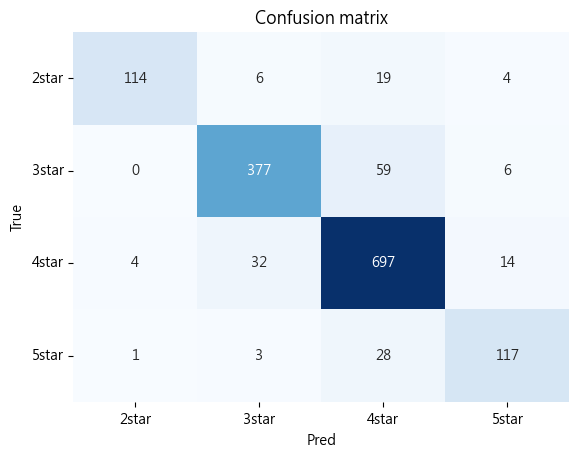

In [204]:
## Plot confusion matrix
fig, ax = plt.subplots()
sns.heatmap(cm, annot=True, fmt="d", ax=ax, cmap=plt.cm.Blues, cbar=False)
ax.set(
    xlabel="Pred",
    ylabel="True",
    xticklabels=classes,
    yticklabels=classes,
    title="Confusion matrix",
)
plt.yticks(rotation=0)

### 3.4 TF-IDF

改使用 TF-IDF 的 DTM 來代表文章，訓練分類模型的效果。

In [205]:
vectorizer = TfidfVectorizer(max_features=1000)
vec_train = vectorizer.fit_transform(X_train)
vec_test = vectorizer.transform(X_test)
vocabulary = vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(columns = vocabulary, data = vec_train.toarray())
tfidf_df

,一下,一位,一到,一夜,一大,一天,一家人,一張,一應俱全,一提,...,高雄,高雄市,鹽埕,鹽埕區,麥當勞,麵包,麻煩,點心,齊全,龍蝦
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.114549,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3450,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.305559,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3451,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.296953,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3452,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.146597,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3453,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [206]:
clf.fit(vec_train, y_train)
y_pred = clf.predict(vec_test)
y_pred_proba = clf.predict_proba(vec_test)

# results
## Accuracy, Precision, Recall, F1-score
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       2star       0.97      0.71      0.82       143
       3star       0.91      0.83      0.87       442
       4star       0.84      0.95      0.89       747
       5star       0.81      0.70      0.76       149

    accuracy                           0.86      1481
   macro avg       0.88      0.80      0.83      1481
weighted avg       0.87      0.86      0.86      1481



效果有好一點點，但沒有差很多。

### 3.5 CV

cross_validate：

- 返回多種指標的結果，包括 f1_macro、recall_macro 和 precision_macro，並能返回每折訓練和測試的時間、模型等詳細信息。

- 更適合用於綜合評估模型的性能並返回模型本身。

In [207]:
clf = LogisticRegression()
vec_train = TfidfVectorizer(max_features=1000).fit_transform(X_train)

scores = cross_validate(clf, vec_train, y_train, cv=5, scoring=("f1_macro", "recall_macro", "precision_macro"), return_estimator=True)
pprint(scores)

{'estimator': [LogisticRegression(),
               LogisticRegression(),
               LogisticRegression(),
               LogisticRegression(),
               LogisticRegression()],
 'fit_time': array([0.03127003, 0.0229156 , 0.02919698, 0.0360086 , 0.03778148]),
 'score_time': array([0.00601506, 0.01835203, 0.00579882, 0.00659299, 0.00975513]),
 'test_f1_macro': array([0.82790681, 0.84659815, 0.84085652, 0.86795407, 0.86187878]),
 'test_precision_macro': array([0.89261671, 0.8995354 , 0.91083013, 0.92506589, 0.93002889]),
 'test_recall_macro': array([0.78557983, 0.80866566, 0.79657492, 0.82752731, 0.81673075])}


cross_val_predict：

- 返回每一折的預測標籤，用來後續生成分類報告（classification_report）。

- 適用於需要比較預測結果的情況。

In [208]:
y_pred = cross_val_predict(clf, vec_train, y_train, cv=5)
print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

       2star       0.99      0.72      0.83       332
       3star       0.93      0.86      0.89      1031
       4star       0.84      0.96      0.90      1744
       5star       0.88      0.69      0.78       348

    accuracy                           0.88      3455
   macro avg       0.91      0.81      0.85      3455
weighted avg       0.89      0.88      0.88      3455



## 4. 比較不同模型效果

In [209]:
# 定義模型訓練組合
## pipeline: 資料處理 vectorizer + 分類器 clf
## 由於 cross-validation 會自動將資料分成 train/test,因此 input 只要給 X, y 即可

def train_cv(vectorizer, clf, X, y):
    ## train classifier
    vec_X = vectorizer.fit_transform(X).toarray()

    ## get cv results
    cv_results = cross_validate(clf, vec_X, y, cv=5, return_estimator=True)
    y_pred = cross_val_predict(clf, vec_X, y, cv=5)
    # classification_report 回傳 dict 方便後續比較
    report = classification_report(y, y_pred, output_dict=True, zero_division=0)
    return report

因為TF-IDF的效果好一點，所以我們選擇使用TF-IDF來實作後面的模型。

In [210]:
vectorizer = TfidfVectorizer(max_features=1000)
clf = LogisticRegression()
result = train_cv(vectorizer, clf, X_train, y_train)

輸出：LogisticRegression、DecisionTree、SVC、RandomForest的各項檢測指標

In [211]:
# 準備訓練資料
X = data["words"]
y = data["hotel_class"]

# 把整個資料集七三切
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=777, stratify=y
)
# 定義模型訓練組合
model_set = dict()
model_set['clf_logistic'] = LogisticRegression(max_iter=1000)
model_set['clf_dtree'] = DecisionTreeClassifier(random_state=777)
model_set['clf_svm'] = svm.SVC(probability=True) # 要使用SVM的predict_proba的話,必須在叫出SVC的時候就將probability設為True
model_set['clf_rf'] = RandomForestClassifier(random_state=777)

# 用 TF-IDF 作為特徵,跑每個模型的 CV
vectorizer = TfidfVectorizer(max_features=1000)
result_set = dict()
for name, clf in model_set.items():
    print(f"--- training {name} ---")
    result_set[name] = train_cv(vectorizer, clf, X_train, y_train)

--- training clf_logistic ---
--- training clf_dtree ---


KeyboardInterrupt: 

分別觀察各個分類模型在不同類別的評估指標表現如何

In [ ]:
result_set['clf_logistic']

{'2star': {'precision': 0.9916666666666667,
  'recall': 0.7168674698795181,
  'f1-score': 0.8321678321678322,
  'support': 332.0},
 '3star': {'precision': 0.9287211740041929,
  'recall': 0.8593598448108632,
  'f1-score': 0.8926952141057934,
  'support': 1031.0},
 '4star': {'precision': 0.8415492957746479,
  'recall': 0.9592889908256881,
  'f1-score': 0.8965702036441586,
  'support': 1744.0},
 '5star': {'precision': 0.8827838827838828,
  'recall': 0.6925287356321839,
  'f1-score': 0.7761674718196457,
  'support': 348.0},
 'accuracy': 0.8793053545586107,
 'macro avg': {'precision': 0.9111802548073475,
  'recall': 0.8070112602870634,
  'f1-score': 0.8494001804343575,
  'support': 3455.0},
 'weighted avg': {'precision': 0.8861405576762471,
  'recall': 0.8793053545586107,
  'f1-score': 0.8770978875170601,
  'support': 3455.0}}

找出f1-score表現最好的模型是哪個，作為我們最終得到的分類器

In [ ]:
max = 0
best_model_name = ""
best_model_metric = "f1-score"

## choose max f1-score model from result_set
for k, v in result_set.items():
    if v['weighted avg'][best_model_metric] > max:
        max = v['weighted avg'][best_model_metric]
        best_model_name = k
print(f"best model: {best_model_name}")
pprint(result_set[best_model_name])

best model: clf_logistic
{'2star': {'f1-score': 0.8321678321678322,
           'precision': 0.9916666666666667,
           'recall': 0.7168674698795181,
           'support': 332.0},
 '3star': {'f1-score': 0.8926952141057934,
           'precision': 0.9287211740041929,
           'recall': 0.8593598448108632,
           'support': 1031.0},
 '4star': {'f1-score': 0.8965702036441586,
           'precision': 0.8415492957746479,
           'recall': 0.9592889908256881,
           'support': 1744.0},
 '5star': {'f1-score': 0.7761674718196457,
           'precision': 0.8827838827838828,
           'recall': 0.6925287356321839,
           'support': 348.0},
 'accuracy': 0.8793053545586107,
 'macro avg': {'f1-score': 0.8494001804343575,
               'precision': 0.9111802548073475,
               'recall': 0.8070112602870634,
               'support': 3455.0},
 'weighted avg': {'f1-score': 0.8770978875170601,
                  'precision': 0.8861405576762471,
                  'recall': 0.87

從結果可以看到LogisticRegression為我們的best model

In [ ]:
# 新增區塊
# 1️ 轉換資料
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# 2️ 訓練模型
model_set['clf_logistic'].fit(X_train_vec, y_train)



LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model_set['clf_logistic'].predict(vectorizer.transform(X_test).toarray())
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       2star       0.97      0.71      0.82       143
       3star       0.91      0.83      0.87       442
       4star       0.84      0.95      0.89       747
       5star       0.81      0.70      0.76       149

    accuracy                           0.86      1481
   macro avg       0.88      0.80      0.83      1481
weighted avg       0.87      0.86      0.86      1481



輸入資料測試模型的效果

In [ ]:
# 用一則範例評論測試看看
test_review = "房間 乾淨 服務 態度 親切 早餐 豐盛 推薦"
model_set['clf_logistic'].predict(vectorizer.transform([test_review]).toarray())

array(['3star'], dtype=object)

## 5. 分析可解釋模型的結果

### 5.1 各字詞特徵的迴歸係數

因為LogisticRegression為我們的best model，所以我們用該模型結合cv tokenizer實作下面的範例

In [ ]:
def plot_coef(logistic_reg_model, feature_names, top_n=10):
    # 選出某個類別的前10大影響力字詞
    log_odds = logistic_reg_model.coef_.T
    coef_df = pd.DataFrame(
        log_odds, 
        columns=logistic_reg_model.classes_, index=feature_names
    )
    for label in coef_df.columns:
        select_words = (
            coef_df[[label]]
            .sort_values(by=label, ascending=False)
            .iloc[np.r_[0:top_n, -top_n:0]]
        )
        word = select_words.index
        count = select_words[label]
        category_colors = np.where(
            select_words[label] >= 0, "darkseagreen", "rosybrown"
        )  # 設定顏色

        fig, ax = plt.subplots(figsize=(8, top_n*0.8))  # 設定畫布
        plt.rcParams["axes.unicode_minus"] = False

        ax.barh(word, count, color=category_colors)
        ax.invert_yaxis()
        ax.set_title(
            "Coeff increase/decrease odds ratio of 「" + label + "」 label the most",
            loc="left",
            size=16,
        )
        ax.set_ylabel("word", size=14)
        ax.set_xlabel("odds ratio", size=14)

從下面的圖表可以了解每個星級類別對應的關鍵字

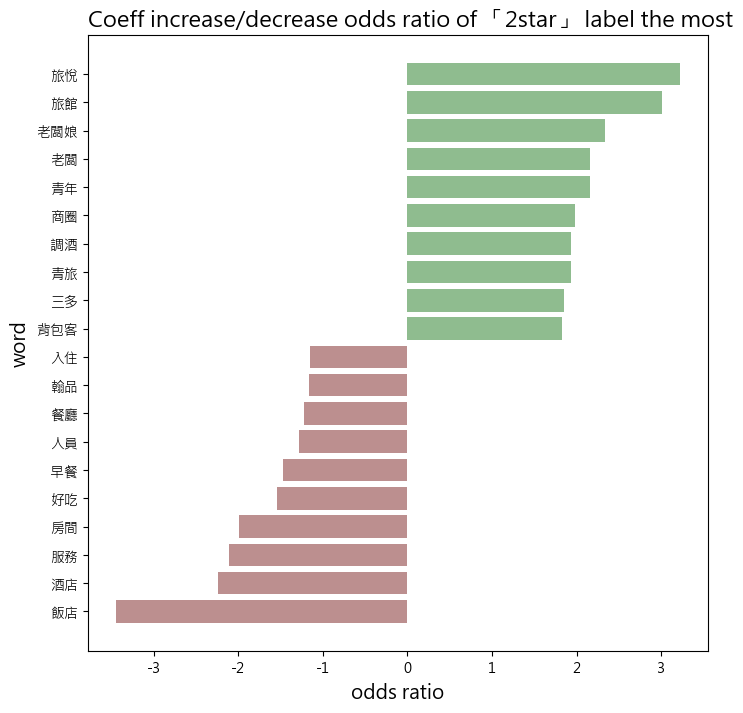

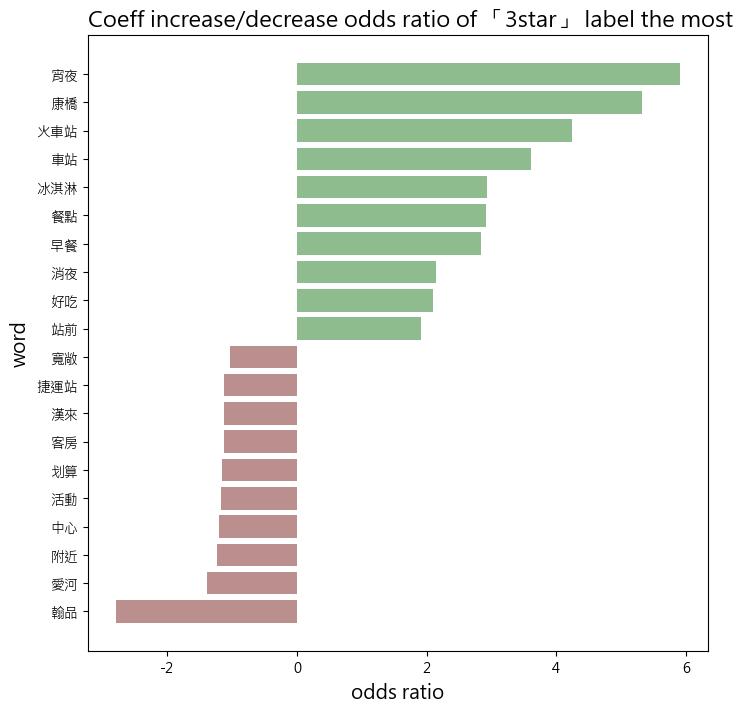

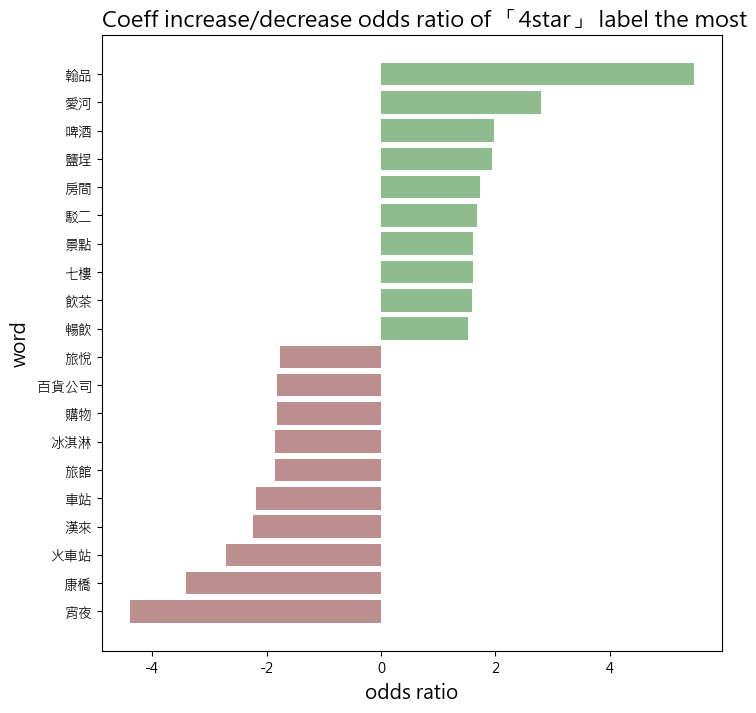

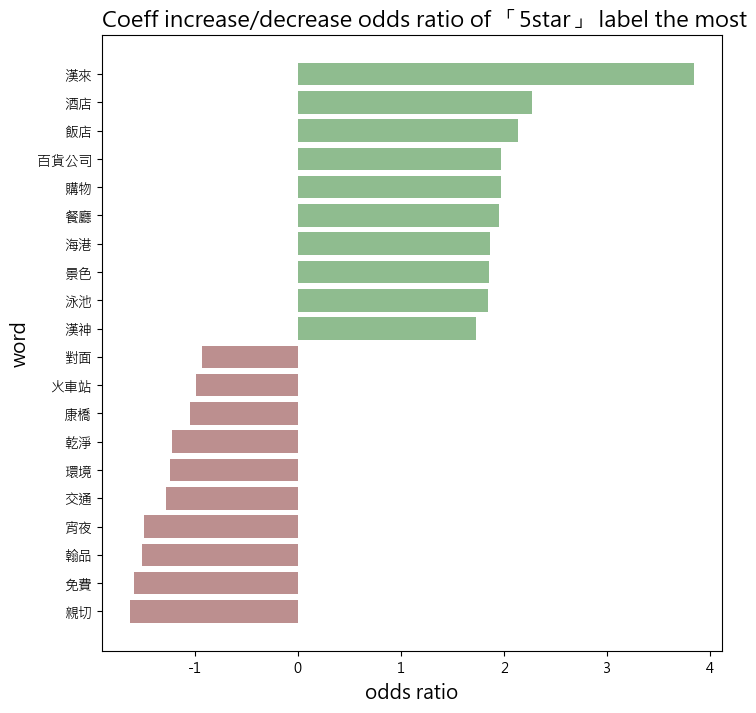

In [ ]:
# 確保 vectorizer 跟 clf_logistic 使用同一份訓練資料配套
vectorizer = TfidfVectorizer(max_features=1000)
vec_train = vectorizer.fit_transform(X_train)
model_set['clf_logistic'] = LogisticRegression(max_iter=1000)
model_set['clf_logistic'].fit(vec_train, y_train)

plot_coef(
    logistic_reg_model=model_set['clf_logistic'],
    feature_names=vectorizer.get_feature_names_out(),
    top_n=10
)

新增停用詞

In [ ]:
import jieba.posseg as pseg

# 1. 重新精簡停用詞：只放「絕對無意義」的詞，把「乾淨、舒適」拿掉
core_stopwords = set(stopWords + [
    '飯店', '酒店', '旅館', '感覺', '覺得', '入住', '真的', '真得', '一個', 
    '發現', '結果', '甚至', '整體', '地方', '內容', '下次', '瀚品', '漢來',
    '有著', '樣樣', '連住', '還算', '沒話', '看著', '看得到', '看得', '要來', '整間', '超有', '小點',
    '看得到', '不負', '沒給', '可供', '有現', '有著', '要來'
])

def balanced_filter(text):
    words = pseg.cut(text.replace(" ", ""))
    # 允許：名詞(n)、形容詞(a)、動詞(v)
    # 排除：地名(ns)、人名(nr)、機構名(nt)、代名詞(r)
    allowed_pos = {'n', 'a', 'v'} 
    
    res = []
    for word, flag in words:
        if flag in allowed_pos and word not in core_stopwords and len(word) > 1:
            res.append(word)
    return " ".join(res)

# 套用新的過濾邏輯
X_train_final = X_train.apply(balanced_filter)

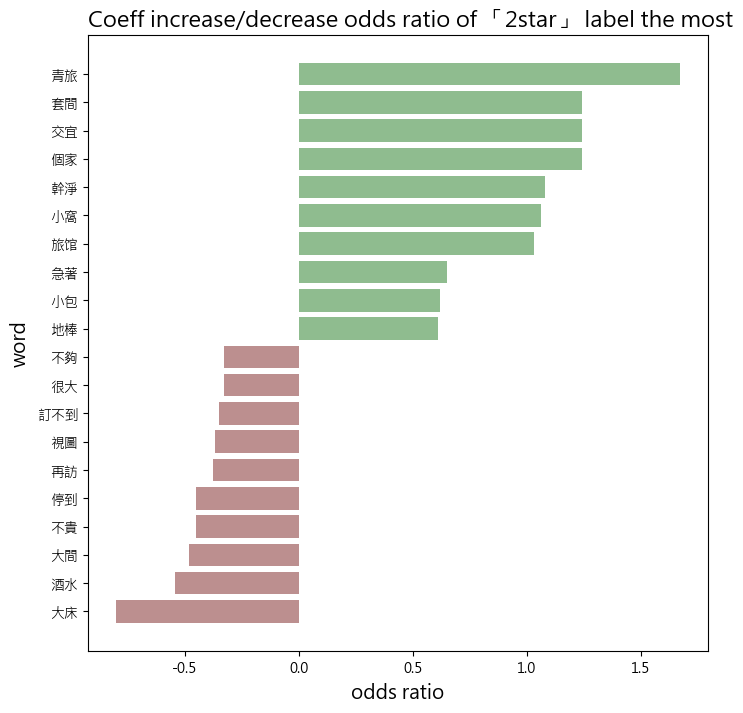

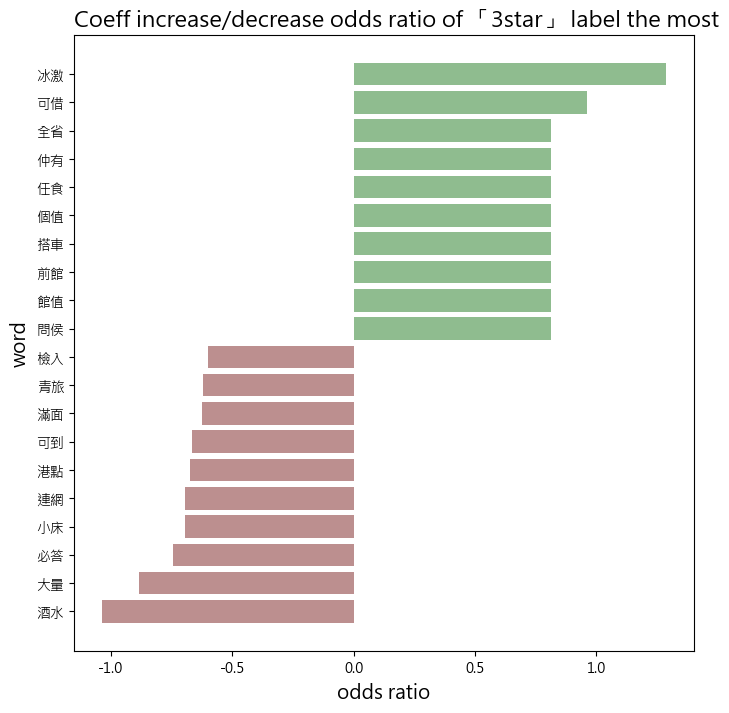

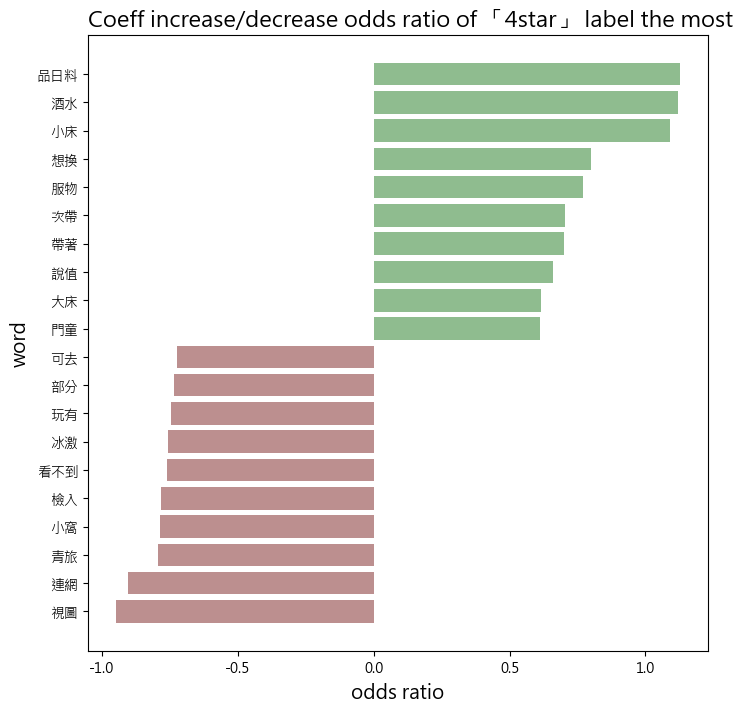

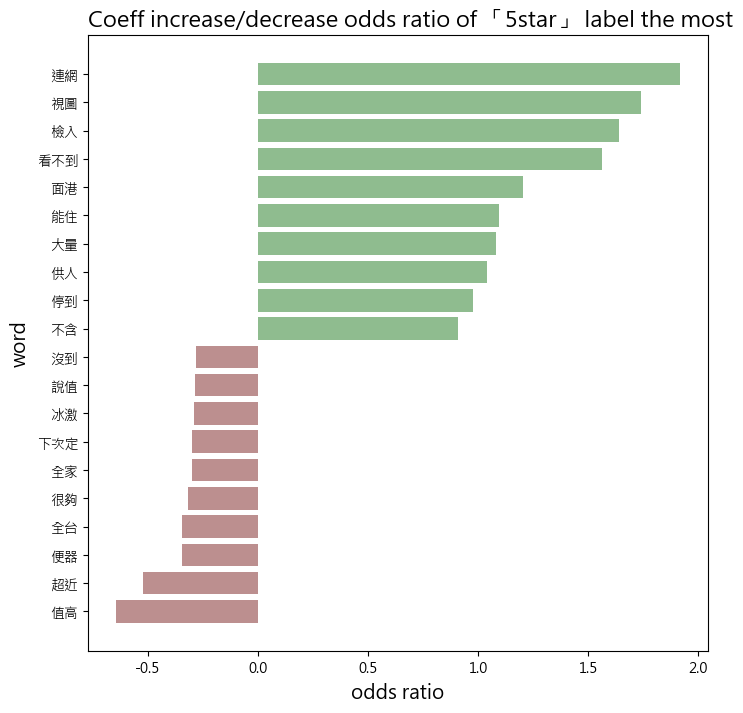

In [ ]:
from sklearn.linear_model import LogisticRegression

# 1. 初始化模型 (如果之前沒宣告過)
clf_logistic = LogisticRegression(max_iter=1000)

# 2. 設定 Vectorizer 參數
vectorizer = TfidfVectorizer(
    max_features=500, 
    max_df=0.4,    # 過濾掉太常見的詞 (如: 飯店、房間)
    min_df=2       # 至少出現兩次的詞
)

# 3. 轉換資料與訓練
# 請確保 X_train_final 是你經過前面詞性過濾後的資料
vec_train_final = vectorizer.fit_transform(X_train_final)
clf_logistic.fit(vec_train_final, y_train)

# 4. 繪圖
# 這裡確保傳入的是剛剛 fit 好的 clf_logistic
plot_coef(
    logistic_reg_model=clf_logistic,
    feature_names=vectorizer.get_feature_names_out(),
    top_n=10
)

 從 2 星到 5 星，住客的關注點從 「人情味與空間感」 (2★)-> 「餐飲細節」 (3★)->  「專業服務」 (4★) -> 「設施與景觀」 (5★) 遞進。負向係數的啟示： 會發現許多「基本優點」（如：不貴、乾淨、有現）在 5 星級模型中是負向係數。

## 6. 用訓練好的分類器檢視各星級的詳細分類表現

前面我們訓練好了分類器,這邊進一步觀察模型對各星級飯店的分類細節。
特別是看模型在哪些星級分類最準、哪些容易混淆,以及錯誤分類的樣本長什麼樣。

In [ ]:
# 不需要另外讀資料,直接用前面切分好的 test set
ct = pd.DataFrame({
    'content': X_test.apply(lambda _: ''),   # 先佔位,下面再把原 content 補回
    'words': X_test.values,
    'hotel_class': y_test.values,
    'artUrl': ['test_' + str(i) for i in range(len(X_test))]
}, index=X_test.index)

# 把原始 content 補回來 (用 index 對應)
ct['content'] = data.loc[X_test.index, 'content'].values

ct.head()

,content,words,hotel_class,artUrl
3816,已數不清入住康橋多少次了之前出差若提早到達都能幸運的提前入房稍作休息此次可能因為前一晚房客較...,數不清 入住 康橋 多少次 出差 提早 到達 幸運 提前 入房 稍作 休息 前一晚 房客 時...,3star,test_0
2658,原本打算入住義大皇家酒店但是因為因緣際會下改成高雄翰品酒店覺得服務態度非常好房間也很時尚高級...,打算 入住 義大 皇家 酒店 因緣際會 改成 高雄 翰品 酒店 服務 態度 房間 時尚 高級...,4star,test_1
1056,房間寬敞明亮服務人員態度親切有禮早餐豐勝吃到飽現點現做熱騰騰的喔下次有機會來高雄還想來入住喔...,房間 寬敞 明亮 服務 人員 態度 親切 有禮 早餐 豐勝 吃到飽 現點現 熱騰騰 下次 機...,4star,test_2
4000,好好好謝謝親朋好友給我滿滿的祝福也祝福和我同一天生日的朋友生日快樂願妳你們心想事成平安快樂愛...,謝謝 親朋好友 給我 滿滿 祝福 祝福 同一 生日 朋友 生日快樂 心想事成 平安 快樂,3star,test_3
4093,這是我第一次去高雄和我在這裏住了晚工作人員都非常有禮貌友好和樂於助人和房間很乾淨和舒適酒店提...,高雄 工作 人員 禮貌 友好 樂於助人 房間 乾淨 舒適 酒店 提供 早餐 晚餐 客人 服務...,3star,test_4


In [ ]:
# test set 已經清理過,這邊直接確認大小
print(f"test set 共 {len(ct)} 則評論")
ct.head()

test set 共 1481 則評論


,content,words,hotel_class,artUrl
3816,已數不清入住康橋多少次了之前出差若提早到達都能幸運的提前入房稍作休息此次可能因為前一晚房客較...,數不清 入住 康橋 多少次 出差 提早 到達 幸運 提前 入房 稍作 休息 前一晚 房客 時...,3star,test_0
2658,原本打算入住義大皇家酒店但是因為因緣際會下改成高雄翰品酒店覺得服務態度非常好房間也很時尚高級...,打算 入住 義大 皇家 酒店 因緣際會 改成 高雄 翰品 酒店 服務 態度 房間 時尚 高級...,4star,test_1
1056,房間寬敞明亮服務人員態度親切有禮早餐豐勝吃到飽現點現做熱騰騰的喔下次有機會來高雄還想來入住喔...,房間 寬敞 明亮 服務 人員 態度 親切 有禮 早餐 豐勝 吃到飽 現點現 熱騰騰 下次 機...,4star,test_2
4000,好好好謝謝親朋好友給我滿滿的祝福也祝福和我同一天生日的朋友生日快樂願妳你們心想事成平安快樂愛...,謝謝 親朋好友 給我 滿滿 祝福 祝福 同一 生日 朋友 生日快樂 心想事成 平安 快樂,3star,test_3
4093,這是我第一次去高雄和我在這裏住了晚工作人員都非常有禮貌友好和樂於助人和房間很乾淨和舒適酒店提...,高雄 工作 人員 禮貌 友好 樂於助人 房間 乾淨 舒適 酒店 提供 早餐 晚餐 客人 服務...,3star,test_4


觀察一下資料集的分佈狀況

In [ ]:
ct['hotel_class'].value_counts()

hotel_class
4star    747
3star    442
5star    149
2star    143
Name: count, dtype: int64

直接用 best model 預測 test set 的 hotel_class

In [ ]:
# 2. 重新宣告並 Fit 向量化工具 (這會決定特徵數量，例如 500)
vectorizer = TfidfVectorizer(max_features=500, max_df=0.4, min_df=2)
vec_train = vectorizer.fit_transform(X_train_final) 

# 3. 重新訓練模型 (讓模型記住這 500 個特徵)
clf_logistic = LogisticRegression(max_iter=1000)
clf_logistic.fit(vec_train, y_train)

# 4. 預測時，使用「同一個」vectorizer 轉換測試集
# 這裡不需要加 .toarray()，LogisticRegression 可以直接收稀疏矩陣，速度更快
X_test_cleaned = X_test.apply(balanced_filter) # 測試集也要用同樣的過濾邏輯
vec_test = vectorizer.transform(X_test_cleaned)

y_pred = clf_logistic.predict(vec_test)

從 classification report 可以觀察:
- 哪個星級的飯店最容易被正確分類 (通常是極端的 5 星和 2 星)
- 哪些星級之間容易混淆 (例如 4 星和 5 星的評論語言風格可能很像)
- 各星級的 recall 和 precision 差異

In [ ]:
ct['pred'] = y_pred
ct.loc[:, ['words', 'hotel_class', 'pred']]

,words,hotel_class,pred
3816,數不清 入住 康橋 多少次 出差 提早 到達 幸運 提前 入房 稍作 休息 前一晚 房客 時...,3star,4star
2658,打算 入住 義大 皇家 酒店 因緣際會 改成 高雄 翰品 酒店 服務 態度 房間 時尚 高級...,4star,4star
1056,房間 寬敞 明亮 服務 人員 態度 親切 有禮 早餐 豐勝 吃到飽 現點現 熱騰騰 下次 機...,4star,4star
4000,謝謝 親朋好友 給我 滿滿 祝福 祝福 同一 生日 朋友 生日快樂 心想事成 平安 快樂,3star,4star
4093,高雄 工作 人員 禮貌 友好 樂於助人 房間 乾淨 舒適 酒店 提供 早餐 晚餐 客人 服務...,3star,3star
...,...,...,...
4625,舒適 有家 感覺 他間 青年 旅館 感受 不到 附近 商家 百貨公司 附近 交通 發達 下次 再來,2star,4star
415,高雄 印象 深刻 美景 舒適 酒店 房間 一流 餐廳 設施 員工 專業 熱情 大部分 酒店 ...,5star,4star
3944,地點 超好 火車站 捷運 火車 方便 四周 生活 機能 熱鬧 晚上 餐廳 選擇 房間 簡潔 ...,3star,4star
4106,次來 康橋 宵夜 特別 好吃 豆花 還有旦 推薦 服務 態度 親切 昨天 六合 夜市,3star,4star


將錯誤分類的結果篩選出來

In [ ]:
false_pred = ct.query("hotel_class != pred").loc[:, ['words', 'hotel_class', 'pred']]
false_pred

,words,hotel_class,pred
3816,數不清 入住 康橋 多少次 出差 提早 到達 幸運 提前 入房 稍作 休息 前一晚 房客 時...,3star,4star
4000,謝謝 親朋好友 給我 滿滿 祝福 祝福 同一 生日 朋友 生日快樂 心想事成 平安 快樂,3star,4star
110,留在 出差 高雄 寶石 酒店 漂亮 裝修 現在 改進 說明 坐落 城市 中心 俯瞰 港口 樓...,5star,4star
3445,久久 一次 高雄 出差 火車站 看到 飯店 服務 人員 親切 主動 幫忙 升級 房型 貼心 ...,3star,4star
46,樓下 百貨公司 漂亮 港景 適合 親子 旅遊 住宿 停車 交通 方便 附近 捷運 需要 一段,5star,4star
...,...,...,...
356,高雄 快會 發現 高雄 好玩 旅遊 地方 遠離 難看 工業 城區 需要 住宿 地方 一流 購...,5star,4star
4625,舒適 有家 感覺 他間 青年 旅館 感受 不到 附近 商家 百貨公司 附近 交通 發達 下次 再來,2star,4star
415,高雄 印象 深刻 美景 舒適 酒店 房間 一流 餐廳 設施 員工 專業 熱情 大部分 酒店 ...,5star,4star
3944,地點 超好 火車站 捷運 火車 方便 四周 生活 機能 熱鬧 晚上 餐廳 選擇 房間 簡潔 ...,3star,4star


觀察看看 2 星飯店的評論 (最低星級),模型是否會誤判成其他星級

In [ ]:
false_pred.loc[false_pred['hotel_class'] == '2star', :]

,words,hotel_class,pred
4773,旅馆 老板 超级 漂亮 超级 热情 整个 旅馆 感觉 温馨 交谊厅 茶水 布置 简直 超乎 ...,2star,4star
4803,想要 再次 嚐試 青春 氣息 尋覓 年輕人 聚集 青年 旅館 適合 落腳 休憩 捷運站 交通...,2star,4star
4532,店員 服務 態度 超好 星期二 舉辦 國家 交流 活動 十分 不錯 附近 商場 方便 房間 ...,2star,4star
4643,誤打誤撞 二人 房有 獨立 衛浴 房間 空間 十分 清潔 青旅 價錢 酒店 房間 職員 友善...,2star,4star
4489,很棒 優質 旅館 服務 優質 感覺 親切 服務 不錯 感覺 特別 心動 感謝 朋友 介紹 價...,2star,4star
...,...,...,...
4523,服務員 態度 親切 調酒 很棒 住宿 地點 推薦 很棒 給人 溫馨 感覺 住宿 環境 乾淨,2star,4star
4787,進到 三樓 溫馨 空間 桌椅 擺設 交誼廳 提供 桌遊 一群 感到 興奮 躍躍欲試 櫃檯 人...,2star,4star
4587,地點 一流 三多 商圈 新光三越 旁邊 對面 興中 夜市 實在 沒什麼 當天 點多 來到 職...,2star,4star
4817,旅客 背包客 誠摯 推薦 高雄 旅悅 青年 旅社 住戶 員工 親切 美麗 大方 走進 旅社 ...,2star,4star


挑選一則被誤判的 2 星評論觀察看看,分析為何會被預測成其他星級

In [ ]:
# 抓第一筆 2star 被誤判的評論 words
low_mis = false_pred.loc[false_pred['hotel_class'] == '2star']
if len(low_mis) > 0:
    idx = low_mis.index[0]
    pprint(low_mis.loc[idx, 'words'])
else:
    print("沒有 2star 的誤判樣本")

('旅馆 老板 超级 漂亮 超级 热情 整个 旅馆 感觉 温馨 交谊厅 茶水 布置 简直 超乎 想象 卫生间 各种 香水 真是 太棒 分享 不错 地方 超级 '
 '贴心 一来 高雄 已经 喜欢 这里 地理 位置 哪里 方便')


In [ ]:
# 看原始評論內容
if len(low_mis) > 0:
    idx = low_mis.index[0]
    print(ct.loc[idx, 'content'])

非常棒的旅馆老板娘超级漂亮超级热情整个旅馆让人感觉很温馨交谊厅茶水间布置的简直超乎你想象还有卫生间还有各种香水真是太棒了还跟我分享了好多很不错的地方超级贴心的让我一来高雄就已经喜欢上这里啦地理位置非常好去哪里都很方便


之前的 Odds Ratio 圖表可以發現，「老闆娘」、「青旅」、「小窩」、「交宜（廳）」 是 2 星級的強特徵。

誤判情境： 如果一家 5 星級飯店的評論寫道：「飯店很有家的感覺，經理像老闆娘一樣親切，還在交誼廳跟我們聊天，讓我們覺得像待在自己的小窩一樣。」

模型邏輯： 雖然這是好評，但因為這些詞彙在 2 星級數據中出現頻率極高，模型會認為「這聽起來像是一間很棒的青年旅館」，進而將其歸類為 2 星。

## 主題模型
主題模型（Topic Modeling）是一種無監督學習技術，用於從大量文本中自動識別潛在的主題。本次使用LDA模型進行主題分析，並結合視覺化工具與情緒分析，探索文本資料中的主題分佈與情緒趨勢。

In [1]:
import time 
from functools import reduce
from collections import Counter
from pprint import pprint
from wordcloud import WordCloud 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jieba
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel
from gensim.models.ldamulticore import LdaMulticore
from gensim.matutils import corpus2csc, corpus2dense, Sparse2Corpus

import pyLDAvis
import pyLDAvis.gensim_models

In [2]:
import logging
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

In [3]:
# 設定中文字體
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] #使圖中中文能正常顯示
plt.rcParams['axes.unicode_minus'] = False #使負號能夠顯示

## 資料前處理

In [4]:
# 重新讀四家飯店做 LDA (無監督學習,用全部資料效果更好)
df5 = pd.read_excel("./raw_data2/5star.xlsx"); df5["hotel_class"] = "5star"
df4 = pd.read_excel("./raw_data2/4star.xlsx"); df4["hotel_class"] = "4star"
df3 = pd.read_excel("./raw_data2/3star.xlsx"); df3["hotel_class"] = "3star"
df2 = pd.read_excel("./raw_data2/2star.xlsx"); df2["hotel_class"] = "2star"
dcard = pd.concat([df5, df4, df3, df2], ignore_index=True)
dcard["artUrl"] = "all_" + dcard.index.astype(str)
dcard.head(3)

,reviewer,location,contributions,user_helpful_votes,date_posted,rating,title,content,stay_date,trip_type,hotel_class,artUrl
0,JennyYu 已於 2024年11月 發表一則評論,月 發表一則評論\n台灣台北,225.0,6.0,2024年11月,5,✨【愛上高雄漢來飯店的原因】✨,✨【愛上高雄漢來飯店的原因】✨\n這次帶著喜歡庫洛米的Yoyo，入住高雄漢來飯店的三麗鷗主題...,NaN,NaN,5star,all_0
1,ANDYCKH 已於 2024年8月 發表一則評論,月 發表一則評論\n香港,91.0,1.0,2024年8月,5,超可愛Kuromi主題房,"復活節假期帶老婆到高雄看5月天演唱會, 住了3晚漢來大飯店, 原因100%是因為有Kurom...",NaN,NaN,5star,all_1
2,IG denden.travel 已於 2023年12月 發表一則評論,月 發表一則評論\n台灣台北,2465.0,27.0,2023年12月,5,大概是全世界最用心的三麗鷗主題房,大概是全世界最用心的三麗鷗主題房～\n大家好，我是膚淺喜歡被讚美的丹丹，這篇要介紹的是高雄漢...,NaN,NaN,5star,all_2


In [5]:
dcard = dcard.dropna(subset=['content', 'hotel_class'])
# 移除網址、只留下中文字
dcard["content"] = dcard["content"].astype(str).str.replace("(http|https)://\\S+", "", regex=True)
dcard["content"] = dcard["content"].str.replace("[^\u4e00-\u9fa5]+", "", regex=True)
dcard = dcard[dcard["content"].str.len() > 0].reset_index(drop=True)
dcard.head(3)

,reviewer,location,contributions,user_helpful_votes,date_posted,rating,title,content,stay_date,trip_type,hotel_class,artUrl
0,JennyYu 已於 2024年11月 發表一則評論,月 發表一則評論\n台灣台北,225.0,6.0,2024年11月,5,✨【愛上高雄漢來飯店的原因】✨,愛上高雄漢來飯店的原因這次帶著喜歡庫洛米的入住高雄漢來飯店的三麗鷗主題房我們選擇的是美樂蒂和...,NaN,NaN,5star,all_0
1,ANDYCKH 已於 2024年8月 發表一則評論,月 發表一則評論\n香港,91.0,1.0,2024年8月,5,超可愛Kuromi主題房,復活節假期帶老婆到高雄看月天演唱會住了晚漢來大飯店原因是因為有主題房老婆是超級酒店離地鐵站並...,NaN,NaN,5star,all_1
2,IG denden.travel 已於 2023年12月 發表一則評論,月 發表一則評論\n台灣台北,2465.0,27.0,2023年12月,5,大概是全世界最用心的三麗鷗主題房,大概是全世界最用心的三麗鷗主題房大家好我是膚淺喜歡被讚美的丹丹這篇要介紹的是高雄漢來大飯店三...,NaN,NaN,5star,all_2


In [6]:
# 設定繁體中文詞庫
jieba.set_dictionary("./dict/dict.txt")

# 新增stopwords
with open("./dict/stopwords.txt", encoding="utf-8") as f:
    stopWords = [line.strip() for line in f.readlines()]

In [7]:
# 設定斷詞 function
def getToken(row):
    seg_list = jieba.cut(row, cut_all=False)
    seg_list = [w for w in seg_list if w not in stopWords and len(w) > 1]
    return seg_list
dcard = dcard[dcard["content"].notna()]  # 移除 content 欄為 NaN 的列
dcard["words"] = dcard["content"].apply(getToken)

Building prefix dict from c:\Users\User\SMA_G2_PRJ1\dict\dict.txt ...
2026-04-25 19:35:13,419 : DEBUG : Building prefix dict from c:\Users\User\SMA_G2_PRJ1\dict\dict.txt ...
Loading model from cache C:\Users\User\AppData\Local\Temp\jieba.u39b885617fea8e30e122529cfb9d1eb6.cache
2026-04-25 19:35:13,423 : DEBUG : Loading model from cache C:\Users\User\AppData\Local\Temp\jieba.u39b885617fea8e30e122529cfb9d1eb6.cache
Loading model cost 0.740 seconds.
2026-04-25 19:35:14,160 : DEBUG : Loading model cost 0.740 seconds.
Prefix dict has been built successfully.
2026-04-25 19:35:14,160 : DEBUG : Prefix dict has been built successfully.


In [8]:
# 加入自定義的停用詞（可隨時擴充）
extra_stopwords = {
    '提供', '選擇', '下次', '入住', '感覺', '分鐘',"感覺", "覺得", "真的", "飯店", "酒店", 
    "這次", "很多", "可以", "我們", "他們", "自己", "還是", "因為", "所以", "但是", "如果", 
    "就是", "比較"
}

# 合併並轉為 set（效率更高）
stopWords = set(stopWords).union(extra_stopwords)

In [9]:
dcard = dcard[dcard["content"].notna()]  # 移除 content 欄為 NaN 的列
dcard["words"] = dcard["content"].apply(getToken)

# 只保留必要欄位
dcard = dcard[["content", "artUrl", "hotel_class", "date_posted" , "words"]]
dcard.head(3)

,content,artUrl,hotel_class,date_posted,words
0,愛上高雄漢來飯店的原因這次帶著喜歡庫洛米的入住高雄漢來飯店的三麗鷗主題房我們選擇的是美樂蒂和...,all_0,5star,2024年11月,"[愛上, 高雄, 漢來, 原因, 喜歡, 庫洛米, 高雄, 漢來, 三麗鷗, 主題房, 美樂..."
1,復活節假期帶老婆到高雄看月天演唱會住了晚漢來大飯店原因是因為有主題房老婆是超級酒店離地鐵站並...,all_1,5star,2024年8月,"[復活節, 假期, 老婆, 高雄, 看月天, 演唱會, 晚漢來, 原因, 主題房, 老婆, ..."
2,大概是全世界最用心的三麗鷗主題房大家好我是膚淺喜歡被讚美的丹丹這篇要介紹的是高雄漢來大飯店三...,all_2,5star,2023年12月,"[全世界, 用心, 三麗鷗, 主題房, 膚淺, 喜歡, 讚美, 丹丹, 這篇要, 介紹, 高..."


## Lexicon-based主題模型

In [10]:
topic_lexicon = {
    "房間設施": [
        "房間", "客房", "房型", "床", "床墊", "枕頭", "浴室", "浴缸", "淋浴",
        "廁所", "冷氣", "空調", "電視", "冰箱", "設備", "設施", "空間",
        "隔音", "窗戶", "電梯", "熱水"
    ],

    "服務與接待": [
        "服務", "人員", "員工", "櫃檯", "櫃台", "接待", "態度", "親切",
        "熱心", "專業", "協助", "幫忙", "入住", "退房", "房務", "服務員"
    ],

    "餐飲體驗": [
        "早餐", "餐廳", "餐點", "食物", "菜色", "咖啡", "飲料", "晚餐",
        "自助", "buffet", "好吃", "美味", "料理", "點心", "水果"
    ],

    "地點交通": [
        "地點", "位置", "交通", "方便", "便利", "附近", "捷運", "車站",
        "火車站", "高鐵", "機場", "公車", "步行", "走路", "距離",
        "商圈", "夜市", "停車"
    ],

    "價格與CP值": [
        "價格", "價錢", "房價", "便宜", "貴", "划算", "值得", "超值",
        "合理", "優惠", "CP值", "性價比", "物超所值", "推薦"
    ],

    "環境與清潔": [
        "乾淨", "整潔", "清潔", "衛生", "舒適", "舒服", "安靜", "吵",
        "噪音", "老舊", "陳舊", "潮濕", "霉味", "環境", "明亮",
        "寬敞", "漂亮", "高級", "豪華"
    ]
}

將斷詞後的doc['words']轉換成list

In [11]:
docs = dcard['words'].to_list()
docs[0]

['愛上',
 '高雄',
 '漢來',
 '原因',
 '喜歡',
 '庫洛米',
 '高雄',
 '漢來',
 '三麗鷗',
 '主題房',
 '美樂蒂',
 '庫洛米',
 '戀愛',
 '糖果屋',
 '家庭',
 '套房',
 '房間',
 '布置',
 '夢幻',
 '隨手',
 '一拍',
 '美照',
 '雙人床',
 '稍微',
 '一點',
 '完全',
 '影響',
 '超棒',
 '體驗',
 '退房',
 '貼心',
 '服務',
 '接待',
 '姐姐',
 '親切',
 '溫柔',
 '踏進',
 '感受到',
 '賓至如歸',
 '溫暖',
 '退房',
 '遇到',
 '洪仕達',
 '先生',
 '同樣',
 '感受到',
 '漢來',
 '水準',
 '服務',
 '感到',
 '用心',
 '難忘',
 '莫過於',
 '接駁車',
 '司機',
 '何聰坤',
 '先生',
 '悉心',
 '照顧',
 '一路',
 '充滿',
 '感謝',
 '漢來',
 '到達',
 '高鐵',
 '貼心',
 '準備',
 '詢問',
 '需要',
 '心頭',
 '一暖',
 '細心',
 '真誠',
 '對漢來',
 '深刻',
 '美好',
 '印象',
 '漢來',
 '每位',
 '員工',
 '展現出',
 '專業',
 '真誠',
 '態度',
 '高雄',
 '之旅',
 '圓滿',
 '尋找',
 '充滿',
 '溫度',
 '住宿',
 '體驗',
 '高雄',
 '漢來',
 '不二',
 '之選',
 '小小',
 '建議',
 '回程',
 '接駁車',
 '最後',
 '一班在點',
 '太早',
 '希望',
 '未來',
 '延長',
 '期待',
 '住到',
 '面海',
 '房型',
 '感受',
 '高雄',
 '美麗',
 '景致',
 '高雄',
 '漢來',
 '三麗鷗',
 '主題房',
 '家庭',
 '旅行',
 '貼心',
 '服務',
 '台灣']

In [12]:
def classify_lexicon(tokens, topic_lexicon):
    scores = {}

    for topic, keywords in topic_lexicon.items():
        score = sum(1 for word in tokens if word in keywords)
        scores[topic] = score

    max_score = max(scores.values())

    if max_score == 0:
        main_topic = "其他"
    else:
        main_topic = max(scores, key=scores.get)

    return main_topic, scores

對每則評論做主題分類

In [13]:
lexicon_result = dcard["words"].apply(
    lambda x: classify_lexicon(x, topic_lexicon)
)

dcard["lexicon_topic"] = lexicon_result.apply(lambda x: x[0])
dcard["topic_scores"] = lexicon_result.apply(lambda x: x[1])

dcard[["content", "hotel_class", "lexicon_topic", "topic_scores"]].head()

,content,hotel_class,lexicon_topic,topic_scores
0,愛上高雄漢來飯店的原因這次帶著喜歡庫洛米的入住高雄漢來飯店的三麗鷗主題房我們選擇的是美樂蒂和...,5star,服務與接待,"{'房間設施': 2, '服務與接待': 10, '餐飲體驗': 0, '地點交通': 1,..."
1,復活節假期帶老婆到高雄看月天演唱會住了晚漢來大飯店原因是因為有主題房老婆是超級酒店離地鐵站並...,5star,房間設施,"{'房間設施': 3, '服務與接待': 0, '餐飲體驗': 0, '地點交通': 1, ..."
2,大概是全世界最用心的三麗鷗主題房大家好我是膚淺喜歡被讚美的丹丹這篇要介紹的是高雄漢來大飯店三...,5star,房間設施,"{'房間設施': 13, '服務與接待': 8, '餐飲體驗': 5, '地點交通': 2,..."
3,若活動範圍在南高雄算是可以選擇的酒店之一離捷運遠需利用計程車過去每年農曆春節常常會住這邊一晚...,5star,地點交通,"{'房間設施': 1, '服務與接待': 1, '餐飲體驗': 2, '地點交通': 5, ..."
4,我覺得大廳環境不錯但走進去沒人理我好幾分鐘不知道哪裡入住最後是我自己問才知道是找有點久湯裡面...,5star,環境與清潔,"{'房間設施': 1, '服務與接待': 0, '餐飲體驗': 2, '地點交通': 0, ..."


把每個主題分數拆成欄位


In [14]:
topic_score_df = dcard["topic_scores"].apply(pd.Series)

dcard_lexicon = pd.concat([dcard, topic_score_df], axis=1)

dcard_lexicon.head(3)

,content,artUrl,hotel_class,date_posted,words,lexicon_topic,topic_scores,房間設施,服務與接待,餐飲體驗,地點交通,價格與CP值,環境與清潔
0,愛上高雄漢來飯店的原因這次帶著喜歡庫洛米的入住高雄漢來飯店的三麗鷗主題房我們選擇的是美樂蒂和...,all_0,5star,2024年11月,"[愛上, 高雄, 漢來, 原因, 喜歡, 庫洛米, 高雄, 漢來, 三麗鷗, 主題房, 美樂...",服務與接待,"{'房間設施': 2, '服務與接待': 10, '餐飲體驗': 0, '地點交通': 1,...",2,10,0,1,0,0
1,復活節假期帶老婆到高雄看月天演唱會住了晚漢來大飯店原因是因為有主題房老婆是超級酒店離地鐵站並...,all_1,5star,2024年8月,"[復活節, 假期, 老婆, 高雄, 看月天, 演唱會, 晚漢來, 原因, 主題房, 老婆, ...",房間設施,"{'房間設施': 3, '服務與接待': 0, '餐飲體驗': 0, '地點交通': 1, ...",3,0,0,1,0,0
2,大概是全世界最用心的三麗鷗主題房大家好我是膚淺喜歡被讚美的丹丹這篇要介紹的是高雄漢來大飯店三...,all_2,5star,2023年12月,"[全世界, 用心, 三麗鷗, 主題房, 膚淺, 喜歡, 讚美, 丹丹, 這篇要, 介紹, 高...",房間設施,"{'房間設施': 13, '服務與接待': 8, '餐飲體驗': 5, '地點交通': 2,...",13,8,5,2,1,2


看每個主題的評論數量


In [15]:
topic_count = dcard_lexicon["lexicon_topic"].value_counts()

topic_count

lexicon_topic
服務與接待     2157
房間設施       814
地點交通       814
餐飲體驗       537
環境與清潔      396
價格與CP值     145
其他          73
Name: count, dtype: int64

c:\Users\User\anaconda3\envs\sma2026\Lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
c:\Users\User\anaconda3\envs\sma2026\Lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
c:\Users\User\anaconda3\envs\sma2026\Lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


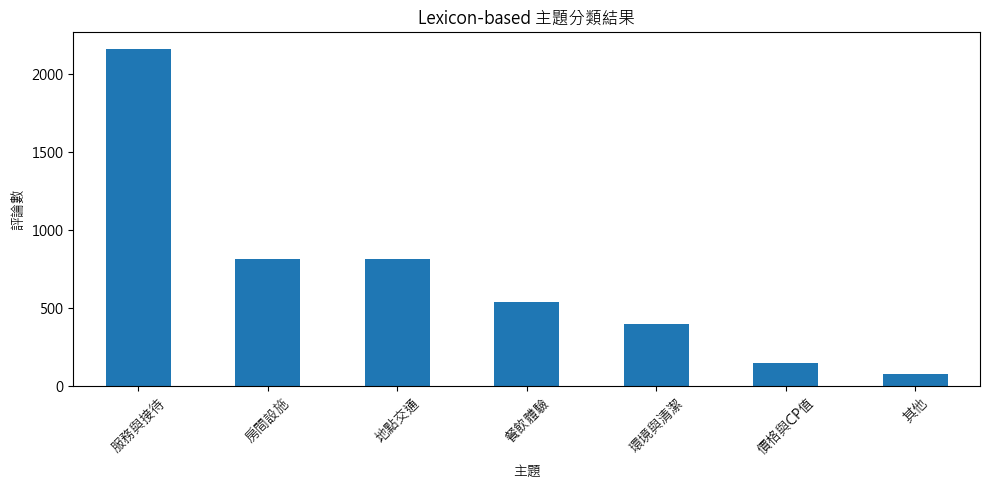

In [16]:
plt.figure(figsize=(10, 5))

topic_count.plot(kind="bar")

plt.title("Lexicon-based 主題分類結果")
plt.xlabel("主題")
plt.ylabel("評論數")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
hotel_topic_count = pd.crosstab(
    dcard_lexicon["hotel_class"],
    dcard_lexicon["lexicon_topic"],
    normalize="index"
)

hotel_topic_count

lexicon_topic,價格與CP值,其他,地點交通,房間設施,服務與接待,環境與清潔,餐飲體驗
hotel_class,,,,,,,
2star,0.061053,0.044211,0.265263,0.166316,0.240000,0.185263,0.037895
3star,0.014936,0.006110,0.190088,0.099796,0.446029,0.054311,0.188730
4star,0.033320,0.016058,0.145725,0.168206,0.502208,0.067041,0.067443
5star,0.022133,0.006036,0.090543,0.340040,0.271630,0.122736,0.146881


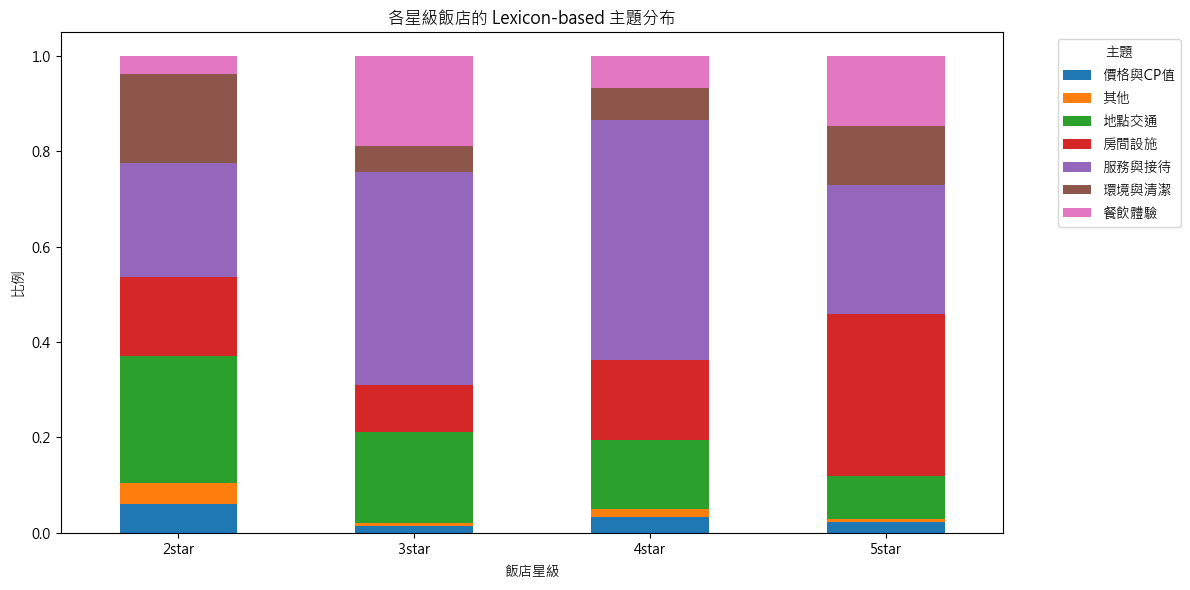

In [18]:
hotel_topic_count.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("各星級飯店的 Lexicon-based 主題分布")
plt.xlabel("飯店星級")
plt.ylabel("比例")
plt.xticks(rotation=0)
plt.legend(title="主題", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## LDA主題模型

### 4.1 正式處理主題分析

將斷詞後的doc['words']轉換成list

In [19]:
docs = dcard['words'].to_list()
docs[0]

['愛上',
 '高雄',
 '漢來',
 '原因',
 '喜歡',
 '庫洛米',
 '高雄',
 '漢來',
 '三麗鷗',
 '主題房',
 '美樂蒂',
 '庫洛米',
 '戀愛',
 '糖果屋',
 '家庭',
 '套房',
 '房間',
 '布置',
 '夢幻',
 '隨手',
 '一拍',
 '美照',
 '雙人床',
 '稍微',
 '一點',
 '完全',
 '影響',
 '超棒',
 '體驗',
 '退房',
 '貼心',
 '服務',
 '接待',
 '姐姐',
 '親切',
 '溫柔',
 '踏進',
 '感受到',
 '賓至如歸',
 '溫暖',
 '退房',
 '遇到',
 '洪仕達',
 '先生',
 '同樣',
 '感受到',
 '漢來',
 '水準',
 '服務',
 '感到',
 '用心',
 '難忘',
 '莫過於',
 '接駁車',
 '司機',
 '何聰坤',
 '先生',
 '悉心',
 '照顧',
 '一路',
 '充滿',
 '感謝',
 '漢來',
 '到達',
 '高鐵',
 '貼心',
 '準備',
 '詢問',
 '需要',
 '心頭',
 '一暖',
 '細心',
 '真誠',
 '對漢來',
 '深刻',
 '美好',
 '印象',
 '漢來',
 '每位',
 '員工',
 '展現出',
 '專業',
 '真誠',
 '態度',
 '高雄',
 '之旅',
 '圓滿',
 '尋找',
 '充滿',
 '溫度',
 '住宿',
 '體驗',
 '高雄',
 '漢來',
 '不二',
 '之選',
 '小小',
 '建議',
 '回程',
 '接駁車',
 '最後',
 '一班在點',
 '太早',
 '希望',
 '未來',
 '延長',
 '期待',
 '住到',
 '面海',
 '房型',
 '感受',
 '高雄',
 '美麗',
 '景致',
 '高雄',
 '漢來',
 '三麗鷗',
 '主題房',
 '家庭',
 '旅行',
 '貼心',
 '服務',
 '台灣']

建立並過濾詞彙表（dictionary），只保留特定條件的詞彙

    no_below=5 出現在少於 5 篇文章中的詞會被移除
    
    no_above=0.99 出現在超過 99% 文件中的詞會被移除

In [20]:
dictionary = Dictionary(docs)

dictionary.filter_extremes(no_below=5, no_above=0.99)
print(dictionary)

2026-04-25 19:36:13,437 : INFO : adding document #0 to Dictionary<0 unique tokens: []>
2026-04-25 19:36:13,624 : INFO : built Dictionary<14518 unique tokens: ['一拍', '一暖', '一班在點', '一路', '一點']...> from 4936 documents (total 135964 corpus positions)
2026-04-25 19:36:13,624 : INFO : Dictionary lifecycle event {'msg': "built Dictionary<14518 unique tokens: ['一拍', '一暖', '一班在點', '一路', '一點']...> from 4936 documents (total 135964 corpus positions)", 'datetime': '2026-04-25T19:36:13.624539', 'gensim': '4.3.3', 'python': '3.11.15 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:12:15) [MSC v.1942 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26200-SP0', 'event': 'created'}
2026-04-25 19:36:13,645 : INFO : discarding 11705 tokens: [('一拍', 1), ('一暖', 1), ('一班在點', 1), ('三麗鷗', 2), ('主題房', 3), ('何聰坤', 1), ('圓滿', 4), ('夢幻', 2), ('太早', 2), ('對漢來', 3)]...
2026-04-25 19:36:13,645 : INFO : keeping 2813 tokens which were in no less than 5 and no more than 4886 (=99.0%) documents
2026-04-25 19:36:13,66

Dictionary<2813 unique tokens: ['一路', '一點', '不二', '之旅', '之選']...>


將斷詞結果建構語料庫(corpus)之後，利用語料庫把每篇文章數字化。
<br>每個詞彙都被賦予一個 ID 及頻率(word_id，word_frequency)。<br>

舉例來說：<br>
第一篇文章數字化結果為：corpus[600]:[(2, 2), (6, 1), (20, 2), .... ]，element 為文章中每個詞彙的 id 和頻率。<br>
代表：'世界'出現2次、'之戰'出現一次...以此類推

In [21]:
for idx, (k, v) in enumerate(dictionary.token2id.items()):
    print(f"{k}: {v}")
    if idx > 10:
        break

一路: 0
一點: 1
不二: 2
之旅: 3
之選: 4
住到: 5
住宿: 6
充滿: 7
先生: 8
到達: 9
印象: 10
原因: 11


In [22]:
pprint(" ".join(dcard['words'].iloc[0]))

('愛上 高雄 漢來 原因 喜歡 庫洛米 高雄 漢來 三麗鷗 主題房 美樂蒂 庫洛米 戀愛 糖果屋 家庭 套房 房間 布置 夢幻 隨手 一拍 美照 雙人床 '
 '稍微 一點 完全 影響 超棒 體驗 退房 貼心 服務 接待 姐姐 親切 溫柔 踏進 感受到 賓至如歸 溫暖 退房 遇到 洪仕達 先生 同樣 感受到 漢來 '
 '水準 服務 感到 用心 難忘 莫過於 接駁車 司機 何聰坤 先生 悉心 照顧 一路 充滿 感謝 漢來 到達 高鐵 貼心 準備 詢問 需要 心頭 一暖 '
 '細心 真誠 對漢來 深刻 美好 印象 漢來 每位 員工 展現出 專業 真誠 態度 高雄 之旅 圓滿 尋找 充滿 溫度 住宿 體驗 高雄 漢來 不二 之選 '
 '小小 建議 回程 接駁車 最後 一班在點 太早 希望 未來 延長 期待 住到 面海 房型 感受 高雄 美麗 景致 高雄 漢來 三麗鷗 主題房 家庭 旅行 '
 '貼心 服務 台灣')


In [23]:
dictionary.doc2bow(dcard['words'].iloc[0])[:10]

[(0, 1),
 (1, 1),
 (2, 1),
 (3, 1),
 (4, 1),
 (5, 1),
 (6, 1),
 (7, 2),
 (8, 2),
 (9, 1)]

將docs轉換成BOW形式<br>
把每篇文件的 token list 轉換成一組 (token_id, count) 的 list

In [24]:
# 建立 Bag-of-words 作為文章的特徵表示
# 用 gensim ldamodel input 需要將文章轉換成 bag of words 
corpus = [dictionary.doc2bow(doc) for doc in docs]

### 4.2 開始訓練 LDA topic model

In [25]:
ldamodel = LdaModel(
    corpus=corpus, # 文檔語料庫
    id2word=dictionary, # 字典
    num_topics=10, # 生成幾個主題數
    random_state=2024, # 亂數
)

2026-04-25 19:36:24,575 : INFO : using symmetric alpha at 0.1
2026-04-25 19:36:24,577 : INFO : using symmetric eta at 0.1
2026-04-25 19:36:24,581 : INFO : using serial LDA version on this node
2026-04-25 19:36:24,581 : INFO : running online (single-pass) LDA training, 10 topics, 1 passes over the supplied corpus of 4936 documents, updating model once every 2000 documents, evaluating perplexity every 4936 documents, iterating 50x with a convergence threshold of 0.001000
2026-04-25 19:36:24,581 : WARNING : too few updates, training might not converge; consider increasing the number of passes or iterations to improve accuracy
2026-04-25 19:36:24,589 : INFO : PROGRESS: pass 0, at document #2000/4936
2026-04-25 19:36:25,717 : INFO : merging changes from 2000 documents into a model of 4936 documents
2026-04-25 19:36:25,721 : INFO : topic #2 (0.100): 0.031*"房間" + 0.030*"服務" + 0.028*"人員" + 0.024*"高雄" + 0.024*"親切" + 0.020*"翰品" + 0.013*"不錯" + 0.013*"住宿" + 0.012*"乾淨" + 0.011*"舒適"
2026-04-25 19:36

### 4.3 查看 LDA 主題代表字

In [26]:
ldamodel.print_topics()

2026-04-25 19:36:30,237 : INFO : topic #0 (0.100): 0.043*"服務" + 0.028*"方便" + 0.027*"房間" + 0.020*"早餐" + 0.018*"乾淨" + 0.017*"交通" + 0.016*"人員" + 0.012*"免費" + 0.012*"位置" + 0.011*"態度"
2026-04-25 19:36:30,241 : INFO : topic #1 (0.100): 0.049*"服務" + 0.031*"人員" + 0.025*"親切" + 0.021*"青年" + 0.021*"房間" + 0.020*"乾淨" + 0.017*"舒適" + 0.016*"高雄" + 0.015*"很棒" + 0.014*"冰淇淋"
2026-04-25 19:36:30,242 : INFO : topic #2 (0.100): 0.038*"服務" + 0.030*"房間" + 0.028*"人員" + 0.024*"親切" + 0.023*"早餐" + 0.022*"高雄" + 0.019*"宵夜" + 0.017*"乾淨" + 0.013*"餐點" + 0.012*"住宿"
2026-04-25 19:36:30,245 : INFO : topic #3 (0.100): 0.025*"服務" + 0.023*"高雄" + 0.018*"早餐" + 0.016*"人員" + 0.016*"住宿" + 0.013*"親切" + 0.013*"環境" + 0.011*"房間" + 0.010*"乾淨" + 0.008*"舒服"
2026-04-25 19:36:30,246 : INFO : topic #4 (0.100): 0.045*"服務" + 0.022*"房間" + 0.021*"高雄" + 0.012*"早餐" + 0.012*"三多" + 0.011*"乾淨" + 0.010*"人員" + 0.010*"旅館" + 0.007*"品質" + 0.007*"態度"
2026-04-25 19:36:30,247 : INFO : topic #5 (0.100): 0.024*"高雄" + 0.021*"房間" + 0.019*"早餐" + 0.015*"地方" + 0

[(0,
  '0.043*"服務" + 0.028*"方便" + 0.027*"房間" + 0.020*"早餐" + 0.018*"乾淨" + 0.017*"交通" + 0.016*"人員" + 0.012*"免費" + 0.012*"位置" + 0.011*"態度"'),
 (1,
  '0.049*"服務" + 0.031*"人員" + 0.025*"親切" + 0.021*"青年" + 0.021*"房間" + 0.020*"乾淨" + 0.017*"舒適" + 0.016*"高雄" + 0.015*"很棒" + 0.014*"冰淇淋"'),
 (2,
  '0.038*"服務" + 0.030*"房間" + 0.028*"人員" + 0.024*"親切" + 0.023*"早餐" + 0.022*"高雄" + 0.019*"宵夜" + 0.017*"乾淨" + 0.013*"餐點" + 0.012*"住宿"'),
 (3,
  '0.025*"服務" + 0.023*"高雄" + 0.018*"早餐" + 0.016*"人員" + 0.016*"住宿" + 0.013*"親切" + 0.013*"環境" + 0.011*"房間" + 0.010*"乾淨" + 0.008*"舒服"'),
 (4,
  '0.045*"服務" + 0.022*"房間" + 0.021*"高雄" + 0.012*"早餐" + 0.012*"三多" + 0.011*"乾淨" + 0.010*"人員" + 0.010*"旅館" + 0.007*"品質" + 0.007*"態度"'),
 (5,
  '0.024*"高雄" + 0.021*"房間" + 0.019*"早餐" + 0.015*"地方" + 0.012*"服務" + 0.011*"食物" + 0.011*"晚餐" + 0.011*"地鐵站" + 0.010*"旅館" + 0.010*"免費"'),
 (6,
  '0.029*"房間" + 0.026*"服務" + 0.017*"高雄" + 0.014*"乾淨" + 0.013*"人員" + 0.013*"方便" + 0.012*"早餐" + 0.012*"捷運" + 0.012*"捷運站" + 0.010*"附近"'),
 (7,
  '0.028*"方便" + 0.0

In [27]:
ldamodel.get_document_topics(corpus[0])

[(3, 0.7653278), (4, 0.22650237)]

### 4.4 查看 LDA 模型指標

In [28]:
# perplexity
perplexity = ldamodel.log_perplexity(corpus)
perplexity

2026-04-25 19:36:38,290 : INFO : -7.051 per-word bound, 132.6 perplexity estimate based on a held-out corpus of 4936 documents with 118434 words


-7.051035312684608

In [29]:
np.exp2(-perplexity)

132.60903955253738

In [30]:
# npmi
NPMI_model_lda = CoherenceModel(model=ldamodel, texts=docs, coherence='c_npmi')
NPMI_lda = NPMI_model_lda.get_coherence()
print('這個主題模型的 PMI score: ', NPMI_lda)

2026-04-25 19:36:41,658 : INFO : using ParallelWordOccurrenceAccumulator<processes=15, batch_size=64> to estimate probabilities from sliding windows
2026-04-25 19:37:09,721 : INFO : 1 batches submitted to accumulate stats from 64 documents (2545 virtual)
2026-04-25 19:37:09,726 : INFO : 2 batches submitted to accumulate stats from 128 documents (4119 virtual)
2026-04-25 19:37:09,728 : INFO : 3 batches submitted to accumulate stats from 192 documents (6551 virtual)
2026-04-25 19:37:09,732 : INFO : 4 batches submitted to accumulate stats from 256 documents (8212 virtual)
2026-04-25 19:37:09,736 : INFO : 5 batches submitted to accumulate stats from 320 documents (10500 virtual)
2026-04-25 19:37:09,738 : INFO : 6 batches submitted to accumulate stats from 384 documents (12819 virtual)
2026-04-25 19:37:09,741 : INFO : 7 batches submitted to accumulate stats from 448 documents (15199 virtual)
2026-04-25 19:37:09,742 : INFO : 8 batches submitted to accumulate stats from 512 documents (17548 v

這個主題模型的 PMI score:  0.020537190735287012


In [31]:
NPMI_model_lda.get_coherence_per_topic()

[0.04140673061129144,
 0.01834664972487504,
 0.051058803452290594,
 0.02300890141121446,
 -0.0009305977308670055,
 0.013763034088650688,
 0.02624396022033488,
 0.008900744226646634,
 0.0010995281571756187,
 0.022474153191257746]

### 4.5 透過指標找出最佳主題數

In [32]:
t0 = time.time()

topic_num_list = np.arange(2, 8)
result = {"topic_num":[], "perplexity":[], "pmi":[]}
model_set = dict()


for topic_num in topic_num_list:
    # perplexity
    model = LdaModel(
        corpus = corpus,
        num_topics = topic_num ,
        id2word=dictionary,
        random_state = 1500,
        passes=5 # 訓練次數
        )
    
    loss = model.log_perplexity(corpus)
    pmi = CoherenceModel(model=model, texts=docs, coherence='c_npmi').get_coherence()
    perplexity = np.exp(-1. * loss)
    
    # model_set[f'k_{topic_num}'] = model
    
    result['topic_num'].append(topic_num)
    result['perplexity'].append(perplexity)
    result['pmi'].append(pmi)
    
print(f"花費時間: {time.time() - t0} sec")

2026-04-25 19:37:17,860 : INFO : using symmetric alpha at 0.5
2026-04-25 19:37:17,863 : INFO : using symmetric eta at 0.5
2026-04-25 19:37:17,867 : INFO : using serial LDA version on this node
2026-04-25 19:37:17,872 : INFO : running online (multi-pass) LDA training, 2 topics, 5 passes over the supplied corpus of 4936 documents, updating model once every 2000 documents, evaluating perplexity every 4936 documents, iterating 50x with a convergence threshold of 0.001000
2026-04-25 19:37:17,873 : INFO : PROGRESS: pass 0, at document #2000/4936
2026-04-25 19:37:19,101 : INFO : merging changes from 2000 documents into a model of 4936 documents
2026-04-25 19:37:19,104 : INFO : topic #0 (0.500): 0.042*"服務" + 0.026*"房間" + 0.022*"人員" + 0.019*"高雄" + 0.013*"親切" + 0.013*"翰品" + 0.010*"很棒" + 0.010*"早餐" + 0.009*"推薦" + 0.009*"住宿"
2026-04-25 19:37:19,106 : INFO : topic #1 (0.500): 0.028*"服務" + 0.026*"房間" + 0.020*"高雄" + 0.019*"人員" + 0.015*"翰品" + 0.013*"乾淨" + 0.012*"舒適" + 0.011*"方便" + 0.011*"親切" + 0.009*"

花費時間: 229.2715413570404 sec


In [33]:
result = pd.DataFrame(result)
result

,topic_num,perplexity,pmi
0,2,842.409729,0.032052
1,3,821.783290,0.037224
2,4,825.036012,0.032300
3,5,828.754906,0.035653
4,6,831.595992,0.047249
5,7,861.251351,0.014490


perplexity：模型對資料的「不確定程度」

越低 : 模型越能「解釋資料」

越高 : 模型越混亂、不準

<Axes: xlabel='topic_num'>

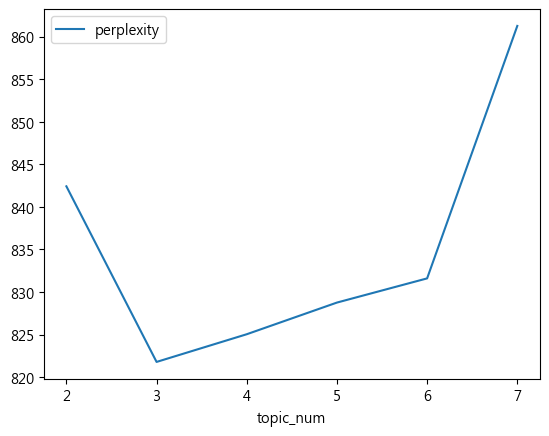

In [34]:
result.plot.line(x='topic_num', y='perplexity')

pmi：同一個 topic 裡的詞，有沒有常一起出現

越高 : 主題越「有意義、可解釋」

越低 : 主題很亂

<Axes: xlabel='topic_num'>

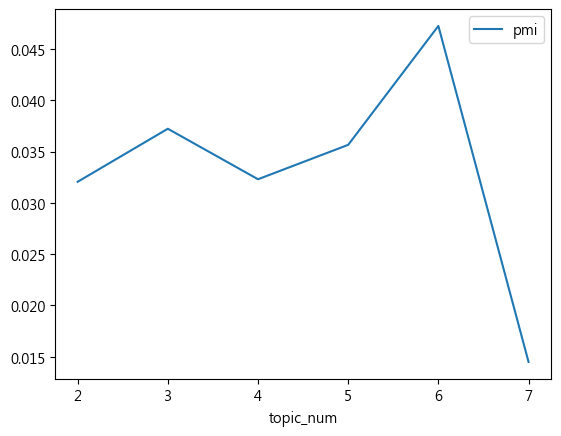

In [35]:
result.plot.line(x='topic_num', y='pmi')

綜合考量模型的解釋力與主題的語意一致性，雖然在 Perplexity 指標中 3 個主題的數值最低，代表對語料擬合最佳，但在 PMI 指標中，6 個主題表現相對較佳，顯示其主題內部詞彙的語意較集中、一致性較好。為兼顧模型效果與主題可解釋性，最終決定採用 6 個主題 作為 LDA 模型的主題數設定。

## 5. 視覺化呈現

接下來，將以主題數 6 來做 LDAvis 的結果分析

In [36]:
best_model = LdaModel(
    corpus = corpus,
    num_topics = 6,
    id2word=dictionary,
    random_state = 1500,
    passes = 5 # 訓練次數
    )

2026-04-25 19:41:19,323 : INFO : using symmetric alpha at 0.16666666666666666
2026-04-25 19:41:19,324 : INFO : using symmetric eta at 0.16666666666666666
2026-04-25 19:41:19,326 : INFO : using serial LDA version on this node
2026-04-25 19:41:19,329 : INFO : running online (multi-pass) LDA training, 6 topics, 5 passes over the supplied corpus of 4936 documents, updating model once every 2000 documents, evaluating perplexity every 4936 documents, iterating 50x with a convergence threshold of 0.001000
2026-04-25 19:41:19,331 : INFO : PROGRESS: pass 0, at document #2000/4936
2026-04-25 19:41:19,882 : INFO : merging changes from 2000 documents into a model of 4936 documents
2026-04-25 19:41:19,889 : INFO : topic #0 (0.167): 0.037*"服務" + 0.028*"房間" + 0.022*"人員" + 0.014*"高雄" + 0.013*"親切" + 0.010*"乾淨" + 0.010*"早餐" + 0.009*"推薦" + 0.009*"很棒" + 0.008*"翰品"
2026-04-25 19:41:19,889 : INFO : topic #4 (0.167): 0.038*"服務" + 0.027*"人員" + 0.022*"高雄" + 0.021*"房間" + 0.020*"翰品" + 0.015*"親切" + 0.013*"住宿" + 0

In [37]:
import gensim
gensim.__version__

'4.3.3'

In [38]:
from pyLDAvis import gensim_models

In [39]:
# 原本 10 個主題的LDA模型
pyLDAvis.enable_notebook()
p = pyLDAvis.gensim_models.prepare(ldamodel, corpus, dictionary)
p

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1      0.049692  0.004134       1        1  15.680432
2      0.086849 -0.027182       2        1  13.312776
4     -0.004450 -0.034513       3        1  11.836994
3      0.026136 -0.069445       4        1  11.105406
0      0.000560  0.042734       5        1  10.651425
5     -0.137060 -0.106026       6        1  10.170324
7     -0.011865  0.074709       7        1   8.031909
6     -0.010415  0.045639       8        1   6.820056
9      0.083650 -0.021378       9        1   6.695358
8     -0.083097  0.091327      10        1   5.695321, topic_info=     Term         Freq        Total Category  logprob  loglift
1227   康橋   619.000000   619.000000  Default  30.0000  30.0000
2598   青年   398.000000   398.000000  Default  29.0000  29.0000
234    方便  1435.000000  1435.000000  Default  28.0000  28.0000
2019   老闆   240.000000   240.000000  Default  27.0000  27.0000
2297   宵夜  1078.000000  1078.000000  Default  26.0000  26.0000
...   ...          ...          ...      ...      ...      ...
60     親切    50.546380  1453.959158  Topic10  -4.8937  -0.4936
279    很棒    43.837646   768.104071  Topic10  -5.0361   0.0021
36     房間    49.978033  2487.841211  Topic10  -4.9050  -1.0421
130    地點    39.700081   702.725725  Topic10  -5.1352  -0.0081
206    設施    36.742918   388.198136  Topic10  -5.2126   0.5080

[741 rows x 6 columns], token_table=      Topic      Freq Term
term                      
1685      4  0.034885   一个
1685      6  0.941888   一个
2084      2  0.969200   一出
1526      6  0.825447   一口
1526      8  0.058960   一口
...     ...       ...  ...
309       6  0.045924   齊全
309       7  0.199005   齊全
309       8  0.010205   齊全
309       9  0.005103   齊全
309      10  0.035719   齊全

[1948 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 3, 5, 4, 1, 6, 8, 7, 10, 9])

In [40]:
# 調整後找出的最佳LDA模型
pyLDAvis.enable_notebook()
p = pyLDAvis.gensim_models.prepare(best_model, corpus, dictionary)
p

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
4     -0.025786 -0.064865       1        1  28.823602
2      0.084800 -0.053047       2        1  27.317335
3      0.070447  0.095625       3        1  20.179295
0      0.033240 -0.175828       4        1  10.156811
1      0.134850  0.140802       5        1   7.774017
5     -0.297551  0.057312       6        1   5.748940, topic_info=     Term         Freq        Total Category  logprob  loglift
234    方便  1323.000000  1323.000000  Default  30.0000  30.0000
2160   翰品   790.000000   790.000000  Default  29.0000  29.0000
627    旅館   508.000000   508.000000  Default  28.0000  28.0000
560    朋友   490.000000   490.000000  Default  27.0000  27.0000
155    早餐  1795.000000  1795.000000  Default  26.0000  26.0000
...   ...          ...          ...      ...      ...      ...
472    地方    57.228875   472.628219   Topic6  -4.7789   0.7449
279    很棒    58.262391   751.177809   Topic6  -4.7610   0.2995
15     員工    47.236916   289.186821   Topic6  -4.9708   1.0443
41     服務    48.457073  4012.573274   Topic6  -4.9453  -1.5604
6      住宿    45.919135   903.120879   Topic6  -4.9991  -0.1228

[456 rows x 6 columns], token_table=      Topic      Freq Term
term                      
1685      3  0.972811   一个
2084      6  0.910573   一出
2623      3  0.984307  一分鐘
1856      5  0.893207  一大床
1720      2  0.160662  一家人
...     ...       ...  ...
2012      1  0.915855  鹽埕區
2012      4  0.065418  鹽埕區
1786      3  0.960321   麵條
1522      1  0.978594   龍蝦
1522      4  0.020821   龍蝦

[972 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[5, 3, 4, 1, 2, 6])

根據觀察可以將上述LDA 分析結果統整如下：

Topic 1 整體住宿體驗與服務評價

Topic 2 早餐與服務品質

Topic 3 房間與清潔品質

Topic 4 住宿設施與附加服務

Topic 5 旅遊與住宿情境（行程/地區）

Topic 6 地點與交通便利性

結論：有部分重疊，每個主題的Terms較難分出差別

In [41]:
pyLDAvis.save_html(p, "lda_tripadvisor.html")

## 6. GuidedLDA

topic 0: 房間設施

topic 1: 服務與接待

topic 2: 餐飲

topic 3: 地點與交通

topic 4: 旅遊體驗

topic 5: 環境品質

In [135]:
import guidedlda

In [136]:
word2id = dictionary.token2id

In [ ]:
# 根據飯店評論常見主題設定種子詞
seed_topic_list = [
    ["房間", "床", "浴室", "空間", "設備"],      # 房間設施
    ["服務", "態度", "人員", "櫃台", "親切"],    # 服務與接待
    ["早餐", "餐廳", "飲料", "食物", "菜色"],    # 餐飲
    ["地點", "交通", "位置", "捷運", "車站"],    # 地點與交通
    ["價格", "便宜", "值得", "划算", "推薦"],    # 旅遊體驗
    ["乾淨", "整潔", "舒適", "安靜", "衛生"],    # 環境品質
]

In [150]:
# 將 seed words 對應到 dictionary 的 token id
# 有些詞可能因 filter_extremes 被移除,需要 skip
seed_topics = {}
missing = []
for t_id, st in enumerate(seed_topic_list):
    for word in st:
        if word in word2id:
            seed_topics[word2id[word]] = t_id
        else:
            missing.append(word)
print(f"有效 seed words: {len(seed_topics)} 個")
if missing:
    print(f"這些詞不在 dictionary (可能被 filter 移除): {missing}")

有效 seed words: 29 個
這些詞不在 dictionary (可能被 filter 移除): ['床']


In [151]:
# (此格跟上格作用相同,保留原範本結構)
seed_topics = {}
for t_id, st in enumerate(seed_topic_list):
    for word in st:
        if word in word2id:
            seed_topics[word2id[word]] = t_id

In [152]:
# guidedlda 需要 DTM 格式作為 input，因此這邊利用 corpus2dense() 方法進行轉換
X = corpus2dense(corpus, len(dictionary), len(corpus)).T.astype(np.int64)

In [153]:
model = guidedlda.GuidedLDA(n_topics=6, n_iter=100, random_state=7, refresh=20)
model.fit(X, seed_topics=seed_topics, seed_confidence=1)

2026-04-24 14:43:34,824 : INFO : n_documents: 4936
2026-04-24 14:43:34,826 : INFO : vocab_size: 2821
2026-04-24 14:43:34,827 : INFO : n_words: 128591
2026-04-24 14:43:34,830 : INFO : n_topics: 6
2026-04-24 14:43:34,833 : INFO : n_iter: 100


2026-04-24 14:43:35,703 : INFO : <0> log likelihood: -1185354
2026-04-24 14:43:36,049 : INFO : <20> log likelihood: -913538
2026-04-24 14:43:36,370 : INFO : <40> log likelihood: -897583
2026-04-24 14:43:36,683 : INFO : <60> log likelihood: -889318
2026-04-24 14:43:36,994 : INFO : <80> log likelihood: -884642
2026-04-24 14:43:37,302 : INFO : <99> log likelihood: -881267


In [ ]:
# 整理／顯示主題模型結果
n_top_words = 10
topic_word = model.topic_word_
# 取得corpus全部的詞彙表
vocab = tuple(dictionary.token2id.keys())

for i, topic_dist in enumerate(topic_word):
    # 依照詞語機率從小到大排序，找出每個主題的前十個關鍵詞
    topic_words = np.array(vocab)[np.argsort(topic_dist)][: -(n_top_words + 1) : -1]
    print("Topic {}: {}".format(i, " ".join(topic_words)))
    

doc_topic = model.doc_topic_ # 文件-主題 分佈
term_freq = tuple(dictionary.cfs.values()) # 每個詞在整個語料中出現的總次數
doc_len = [sum(v for k, v in doc) for doc in corpus] # 每篇文章的長度

## LDAvis
pyLDAvis.enable_notebook()
p = pyLDAvis.prepare(topic_word, doc_topic, doc_len, vocab = vocab, term_frequency = term_freq)
p

Topic 0: 房間 飯店 服務 入住 人員 早餐 不錯 提供 浴室 使用
Topic 1: 服務 人員 飯店 親切 高雄 房間 早餐 乾淨 入住 宵夜
Topic 2: 酒店 房間 服務 早餐 提供 免費 位置 很棒 高雄 不錯
Topic 3: 方便 服務 飯店 高雄 交通 房間 附近 早餐 人員 捷運站
Topic 4: 翰品 高雄 飯店 酒店 入住 活動 參加 人員 推薦 住宿
Topic 5: 高雄 旅館 乾淨 舒適 環境 朋友 服務 房間 親切 旅悅


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1      0.010814 -0.037436       1        1  30.132597
0     -0.126155  0.161755       2        1  18.115317
3     -0.072289 -0.154724       3        1  16.678241
2     -0.153643  0.039183       4        1  16.484967
4      0.246856  0.108077       5        1   9.394225
5      0.094417 -0.116855       6        1   9.194652, topic_info=     Term         Freq        Total Category  logprob  loglift
103    酒店  2098.000000  2098.000000  Default  30.0000  30.0000
2168   翰品  1002.000000  1002.000000  Default  29.0000  29.0000
77     高雄  2387.000000  2387.000000  Default  28.0000  28.0000
242    方便  1341.000000  1341.000000  Default  27.0000  27.0000
74     飯店  2825.000000  2825.000000  Default  26.0000  26.0000
...   ...          ...          ...      ...      ...      ...
7      住宿    95.939284   964.576703   Topic6  -4.8141   0.0786
287    很棒    89.943704   829.923615   Topic6  -4.8787   0.1644
10     入住    92.941494  1470.835803   Topic6  -4.8459  -0.3751
242    方便    87.945177  1341.011045   Topic6  -4.9011  -0.3379
253    舒服    78.951806   491.402036   Topic6  -5.0090   0.5581

[502 rows x 6 columns], token_table=      Topic      Freq Term
term                      
1693      4  0.996677   一个
1864      2  0.997143  一大床
437       5  0.996438   一年
793       1  0.251964   一次
793       3  0.115183   一次
...     ...       ...  ...
2191      3  0.752501   鹽埕
2191      5  0.248325   鹽埕
1794      4  0.996677   麵條
1530      4  0.042236   龍蝦
1530      5  0.957351   龍蝦

[913 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 1, 4, 3, 5, 6])

根據輸出的各主題 top words,可以觀察是否符合預設的 6 大主題
(房間設施 / 服務 / 餐飲 / 地點 / 價格 / 環境品質)。

在價格主題中，無法辨認它突出的特色，因此將seed words 改成五組,希望讓模型更穩定地收斂到這些語意方向。

In [164]:
# topic 0: 房間設施
# topic 1: 服務與接待
# topic 2: 餐飲
# topic 3: 地點與交通
# topic 4: 旅遊體驗
# topic 5: 環境品質

In [ ]:
seed_topic_list = [
    ["房間", "床", "浴室", "空間", "設備", "房型", "浴缸", "交誼廳"],      # 房間設施
    ["服務", "態度", "人員", "櫃台", "親切", "櫃檯", "友好", "老闆娘"],    # 服務與接待
    ["早餐", "餐廳", "飲料", "食物", "菜色", "好吃", "宵夜", "餐點", "晚餐", "啤酒"],    # 餐飲
    ["地點", "交通", "位置", "捷運", "車站", "捷運站","高雄", "愛河", "便利", "駁二", "走路", "火車站", "夜市"],    # 地點與交通
    ["價格", "便宜", "值得", "划算", "推薦", "體驗", "行程", "購物"],    # 旅遊體驗
    ["乾淨", "整潔", "舒適", "安靜", "衛生", "清潔", "舒適度"],    # 環境品質
]
# 重新建 seed_topics
seed_topics = {}
for t_id, st in enumerate(seed_topic_list):
    for word in st:
        if word in word2id:
            seed_topics[word2id[word]] = t_id

In [ ]:
# # 根據飯店評論常見主題設定種子詞
# seed_topic_list = [
#     [# 房間設施
#         "房間", "客房", "房型", "床", "床墊", "枕頭", "浴室", "浴缸", "淋浴",
#         "廁所", "冷氣", "空調", "電視", "冰箱", "設備", "設施", "空間",
#         "隔音", "窗戶", "電梯", "熱水"
#     ],     
#     [# 服務與接待
#         "服務", "人員", "員工", "櫃檯", "櫃台", "接待", "態度", "親切",
#         "熱心", "專業", "協助", "幫忙", "入住", "退房", "房務", "服務員"
#     ],   
#     [# 餐飲
#         "早餐", "餐廳", "餐點", "食物", "菜色", "咖啡", "飲料", "晚餐",
#         "自助", "buffet", "好吃", "美味", "料理", "點心", "水果"
#     ],  
#     [# 地點與交通
#         "地點", "位置", "交通", "方便", "便利", "附近", "捷運", "車站",
#         "火車站", "高鐵", "機場", "公車", "步行", "走路", "距離",
#         "商圈", "夜市", "停車"
#     ],    
#     [# 價格/CP 值
#         "價格", "價錢", "房價", "便宜", "貴", "划算", "值得", "超值",
#         "合理", "優惠", "CP值", "性價比", "物超所值", "推薦"
#     ],  
#     [# 環境品質
#         "乾淨", "整潔", "清潔", "衛生", "舒適", "舒服", "安靜", "吵",
#         "噪音", "老舊", "陳舊", "潮濕", "霉味", "環境", "明亮",
#         "寬敞", "漂亮", "高級", "豪華"
#     ]    
# ]

In [162]:
model = guidedlda.GuidedLDA(n_topics=6, n_iter=100, random_state=7, refresh=20)
model.fit(X, seed_topics=seed_topics, seed_confidence=1)

2026-04-24 15:03:17,591 : INFO : n_documents: 4936
2026-04-24 15:03:17,593 : INFO : vocab_size: 2821
2026-04-24 15:03:17,593 : INFO : n_words: 128591
2026-04-24 15:03:17,595 : INFO : n_topics: 6
2026-04-24 15:03:17,596 : INFO : n_iter: 100
2026-04-24 15:03:18,371 : INFO : <0> log likelihood: -1164479
2026-04-24 15:03:18,688 : INFO : <20> log likelihood: -915507
2026-04-24 15:03:19,001 : INFO : <40> log likelihood: -897497
2026-04-24 15:03:19,309 : INFO : <60> log likelihood: -887255
2026-04-24 15:03:19,621 : INFO : <80> log likelihood: -882725
2026-04-24 15:03:19,928 : INFO : <99> log likelihood: -880439


In [163]:
n_top_words = 10
topic_word = model.topic_word_

for i, topic_dist in enumerate(topic_word):
    topic_words = np.array(vocab)[np.argsort(topic_dist)][: -(n_top_words + 1) : -1]
    print("Topic {}: {}".format(i, " ".join(topic_words)))
    

doc_topic = model.doc_topic_
term_freq = tuple(dictionary.cfs.values())
doc_len = [sum(v for k, v in doc) for doc in corpus]

## LDAvis
pyLDAvis.enable_notebook()
p = pyLDAvis.prepare(topic_word, doc_topic, doc_len, vocab = vocab, term_frequency = term_freq)
p

Topic 0: 房間 飯店 服務 入住 早餐 不錯 人員 浴室 使用 漢來
Topic 1: 服務 人員 飯店 親切 高雄 入住 房間 翰品 乾淨 舒適
Topic 2: 服務 早餐 宵夜 房間 飯店 人員 好吃 乾淨 高雄 康橋
Topic 3: 方便 飯店 服務 高雄 房間 附近 交通 捷運站 乾淨 人員
Topic 4: 高雄 旅館 朋友 翰品 旅悅 青年 感覺 飯店 親切 歷史
Topic 5: 酒店 房間 服務 早餐 位置 提供 免費 很棒 高雄 乾淨


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1     -0.060961 -0.026878       1        1  23.733526
2      0.034731 -0.121163       2        1  18.333313
3     -0.020675 -0.151718       3        1  17.144750
0      0.185291  0.187055       4        1  15.716302
5      0.120877 -0.015801       5        1  15.107543
4     -0.259263  0.128506       6        1   9.964566, topic_info=     Term         Freq        Total Category  logprob  loglift
103    酒店  2098.000000  2098.000000  Default  30.0000  30.0000
2305   宵夜   806.000000   806.000000  Default  29.0000  29.0000
242    方便  1340.000000  1340.000000  Default  28.0000  28.0000
2168   翰品  1002.000000  1002.000000  Default  27.0000  27.0000
163    早餐  1809.000000  1809.000000  Default  26.0000  26.0000
...   ...          ...          ...      ...      ...      ...
75     體驗    63.971683   237.741507   Topic6  -5.2998   0.9934
103    酒店    95.952527  2098.041488   Topic6  -4.8944  -0.7788
480    地方    69.968091   430.602224   Topic6  -5.2102   0.4890
346    舒適    73.965697  1257.079120   Topic6  -5.1547  -0.5268
7      住宿    70.967493   964.515484   Topic6  -5.1960  -0.3033

[486 rows x 6 columns], token_table=      Topic      Freq Term
term                      
1569      1  0.993477   一一
1693      5  0.996596   一个
929       1  0.060538   一張
929       4  0.938347   一張
2006      1  0.043441   一瓶
...     ...       ...  ...
77        6  0.164191   高雄
1208      1  0.997393  高雄人
2542      2  0.994329   鹹粥
2191      3  0.880580   鹽埕
2191      6  0.120421   鹽埕

[903 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 3, 4, 1, 6, 5])

從 PyLDAVis 的視覺化結果來看，各主題間大致有明顯區隔，且高頻詞與種子詞匹配良好，顯示模型已能穩定辨識語料中的潛在主題結構

## 主題分佈的應用，搭配其他文章資訊 (LDA)

In [500]:
# 取得每條新聞的主題分佈
topics_doc = best_model.get_document_topics(corpus)

In [501]:
topics_doc[0]

[(4, 0.87318283), (5, 0.11995611)]

#### 將 LDA 模型推論後的每篇文件的 主題分布（也就是 𝜃）轉換成一個 NumPy 矩陣（array）

In [502]:
# 把 gensim 的稀疏表示法轉成稀疏矩陣
m_theta = corpus2csc(topics_doc).T.toarray() # 倒置讓shape變為(num_docs, num_topics)
m_theta

array([[0.        , 0.        , 0.        , 0.        , 0.87317526,
        0.11996367],
       [0.        , 0.222175  , 0.        , 0.14872268, 0.61470366,
        0.        ],
       [0.        , 0.15068221, 0.14930958, 0.26204628, 0.43400002,
        0.        ],
       ...,
       [0.66289085, 0.        , 0.        , 0.21145484, 0.06863371,
        0.04986965],
       [0.60153484, 0.        , 0.11046542, 0.        , 0.16361147,
        0.12001146],
       [0.17284885, 0.06411991, 0.11948755, 0.16906875, 0.33826655,
        0.13620837]])

In [503]:
# 將主題的機率分布轉換成主題標籤
dcard['topic_label'] = m_theta.argmax(axis=1) + 1

#### 統計一下各個主題的數量

In [504]:
dcard['topic_label'].value_counts()

topic_label
3    1752
5    1613
4     666
1     459
2     223
6     223
Name: count, dtype: int64

In [505]:
dcard.head()

,content,artUrl,hotel_class,date_posted,words,topic_label
0,愛上高雄漢來飯店的原因這次帶著喜歡庫洛米的入住高雄漢來飯店的三麗鷗主題房我們選擇的是美樂蒂和...,all_0,5star,2024年11月,"[愛上, 高雄, 漢來, 原因, 喜歡, 庫洛米, 高雄, 漢來, 三麗鷗, 主題房, 美樂...",5
1,復活節假期帶老婆到高雄看月天演唱會住了晚漢來大飯店原因是因為有主題房老婆是超級酒店離地鐵站並...,all_1,5star,2024年8月,"[復活節, 假期, 老婆, 高雄, 看月天, 演唱會, 晚漢來, 原因, 主題房, 老婆, ...",5
2,大概是全世界最用心的三麗鷗主題房大家好我是膚淺喜歡被讚美的丹丹這篇要介紹的是高雄漢來大飯店三...,all_2,5star,2023年12月,"[全世界, 用心, 三麗鷗, 主題房, 膚淺, 喜歡, 讚美, 丹丹, 這篇要, 介紹, 高...",5
3,若活動範圍在南高雄算是可以選擇的酒店之一離捷運遠需利用計程車過去每年農曆春節常常會住這邊一晚...,all_3,5star,2023年5月,"[活動, 範圍, 高雄, 算是, 之一離, 捷運, 遠需, 利用, 計程車, 過去, 每年,...",4
4,我覺得大廳環境不錯但走進去沒人理我好幾分鐘不知道哪裡入住最後是我自己問才知道是找有點久湯裡面...,all_4,5star,2023年4月,"[大廳, 環境, 不錯, 走進去, 沒人理, 幾分鐘, 知道, 最後, 問才, 知道, 久湯...",4


Topic 1 整體住宿體驗與服務評價

Topic 2 早餐與服務品質

Topic 3 房間與清潔品質

Topic 4 住宿設施與附加服務

Topic 5 旅遊與住宿情境（行程/地區）

Topic 6 地點與交通便利性

#### 查看每個飯店星級下的主題分布

In [506]:
dcard.groupby('hotel_class')['topic_label'].value_counts(normalize=True)

hotel_class  topic_label
2star        6              0.385263
             1              0.231579
             4              0.162105
             5              0.107368
             3              0.080000
             2              0.033684
3star        3              0.765105
             4              0.080109
             5              0.063815
             1              0.047522
             2              0.040054
             6              0.003394
4star        5              0.558410
             3              0.207949
             1              0.104376
             4              0.065436
             2              0.050181
             6              0.013649
5star        4              0.619718
             5              0.154930
             3              0.138833
             2              0.046278
             1              0.038229
             6              0.002012
Name: proportion, dtype: float64

In [507]:
hotel_topic = dcard.groupby('hotel_class')['topic_label'].value_counts(normalize=True).unstack()
hotel_topic

topic_label,1,2,3,4,5,6
hotel_class,,,,,,
2star,0.231579,0.033684,0.080000,0.162105,0.107368,0.385263
3star,0.047522,0.040054,0.765105,0.080109,0.063815,0.003394
4star,0.104376,0.050181,0.207949,0.065436,0.558410,0.013649
5star,0.038229,0.046278,0.138833,0.619718,0.154930,0.002012


#### 視覺化呈現各星級飯店的主題分布

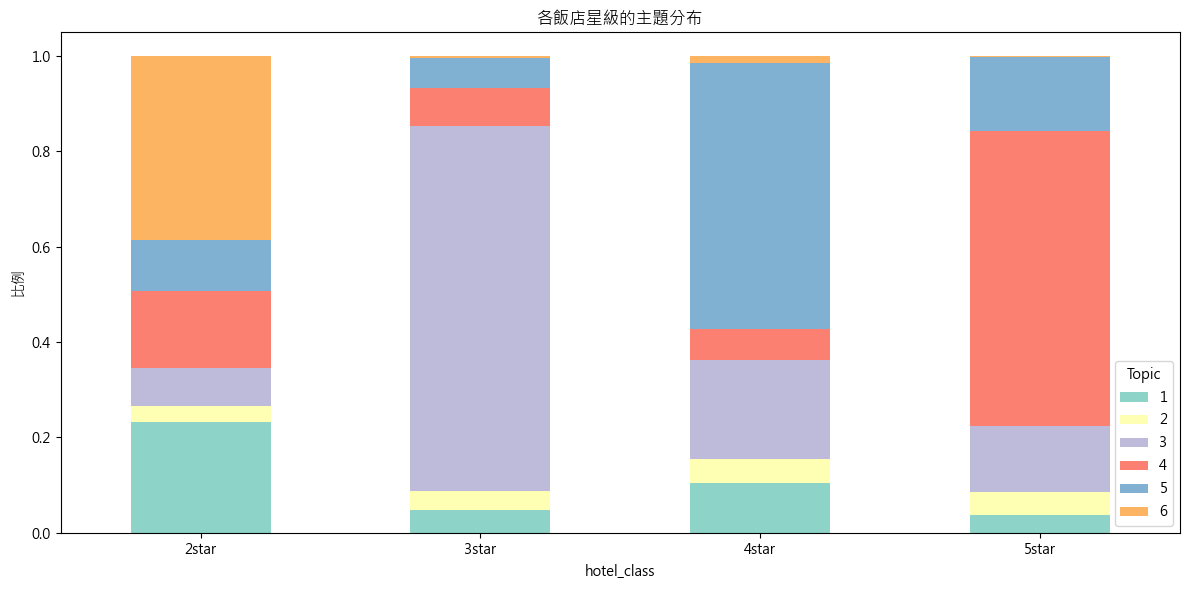

In [508]:
fig, ax = plt.subplots(figsize=(12, 6))
hotel_topic.plot.bar(ax=ax, stacked=True, color=plt.cm.Set3.colors)
ax.legend(loc='lower right', title='Topic')
ax.set_title("各飯店星級的主題分布")
ax.set_ylabel("比例")
plt.xticks(rotation=0)
plt.tight_layout()

Topic 1 整體住宿體驗與服務評價

Topic 2 早餐與服務品質

Topic 3 房間與清潔品質

Topic 4 住宿設施與附加服務

Topic 5 旅遊與住宿情境（行程/地區）

Topic 6 地點與交通便利性

觀察重點:
- 哪些主題在低星級飯店 (2 星) 比例特別高 → 可能是地點與交通便利性
- 哪些主題在高星級飯店 (5 星) 比例特別高 → 可能是關於住宿設施與附加服務